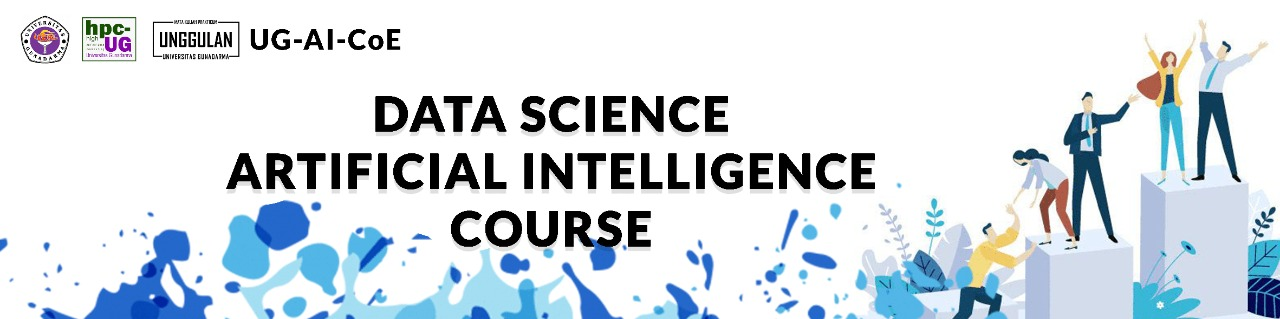


# TUGAS MANDIRI
---

# Customer Segmentation menggunakan Clustering

Project ini mengikuti tahapan **CRISP-DM** dari Business Understanding,
Data Understanding, Data Preparation, Modeling, Evaluation, hingga
Deployment menggunakan Streamlit.


# Customer Segmentation menggunakan Clustering

## 1. Business Understanding — CRISP-DM

### Latar Belakang
Dataset `Customers.csv` berisi karakteristik pelanggan yang dapat digunakan untuk melakukan segmentasi secara unsupervised learning. Karena tidak tersedia label target, project ini menggunakan clustering untuk menemukan kelompok pelanggan berdasarkan kemiripan karakteristik yang tersedia.

link dataset: *https://www.kaggle.com/datasets/datascientistanna/customers-dataset*

### Tujuan Project
Tujuan utama project adalah membentuk segmentasi pelanggan menggunakan K-Means sehingga pelanggan dapat dikelompokkan ke dalam beberapa cluster yang memiliki karakteristik relatif serupa.

### Permasalahan
Tanpa segmentasi, seluruh pelanggan dapat terlihat sebagai satu kelompok besar meskipun memiliki karakteristik yang berbeda. Project ini berusaha menemukan struktur kelompok tersebut secara data-driven.

**Catatan:** Hasil clustering merupakan segmentasi eksploratif pada dataset yang digunakan. Hasil ini tidak secara otomatis membuktikan adanya perbedaan perilaku bisnis atau efektivitas strategi pemasaran tanpa validasi menggunakan data bisnis tambahan.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
path = "../dataset/Customers.csv"

In [6]:
# Membaca dataset

df = pd.read_csv(path)

# Menampilkan 5 baris pertama dari dataset
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


### Pemeriksaan struktur dataset

In [7]:
# menampilkan jumlah baris dan kolom dari dataset

df.shape[0], df.shape[1]

(2000, 8)

In [8]:
# Informasi dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              2000 non-null   int64
 1   Gender                  2000 non-null   str  
 2   Age                     2000 non-null   int64
 3   Annual Income ($)       2000 non-null   int64
 4   Spending Score (1-100)  2000 non-null   int64
 5   Profession              1965 non-null   str  
 6   Work Experience         2000 non-null   int64
 7   Family Size             2000 non-null   int64
dtypes: int64(6), str(2)
memory usage: 151.2 KB


In [9]:
# Tipe Dataset, Jumlah Nilai Kosong

dtype_summary = pd.DataFrame({
    "Atribut": df.columns,
    "Tipe Data": df.dtypes,
    "Jumlah Nilai Kosong": df.isnull().sum()
})

display(dtype_summary)

,Atribut,Tipe Data,Jumlah Nilai Kosong
CustomerID,CustomerID,int64,0
Gender,Gender,str,0
Age,Age,int64,0
Annual Income ($),Annual Income ($),int64,0
Spending Score (1-100),Spending Score (1-100),int64,0
Profession,Profession,str,35
Work Experience,Work Experience,int64,0
Family Size,Family Size,int64,0


Pemeriksaan missing value dilakukan untuk mengetahui apakah terdapat data
yang tidak tersedia pada setiap atribut. Hasil pemeriksaan menunjukkan bahwa
atribut `Profession` memiliki missing value sebanyak 35 dari 2000 observasi
(1,75%), sedangkan atribut lainnya tidak memiliki nilai kosong. Proporsi ini
tergolong kecil dan tidak terkonsentrasi pada atribut lain.


### Pemeriksaan Duplikasi 

In [10]:
# Memeriksa Duplikasi baris

df.duplicated().sum()

np.int64(0)

Pemeriksaan dilakukan pada keseluruhan baris dan atribut.
Pemeriksaan ini bertujuan memastikan bahwa satu pelanggan tidak tercatat
lebih dari satu kali.

Hasil pemeriksaan digunakan sebagai dasar untuk menentukan apakah diperlukan
proses penghapusan data duplikat pada tahap Data Preparation.

### Statistik Deskripsi

In [11]:
# Statistik deskriptif untuk variabel numerik

display(df.describe().T)  # Transpose untuk tampilan yang lebih baik

,count,mean,std,min,25%,50%,75%,max
CustomerID,2000.0,1000.5000,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Age,2000.0,48.9600,28.429747,0.0,25.00,48.0,73.00,99.0
Annual Income ($),2000.0,110731.8215,45739.536688,0.0,74572.00,110045.0,149092.75,189974.0
Spending Score (1-100),2000.0,50.9625,27.934661,0.0,28.00,50.0,75.00,100.0
Work Experience,2000.0,4.1025,3.922204,0.0,1.00,3.0,7.00,17.0
Family Size,2000.0,3.7685,1.970749,1.0,2.00,4.0,5.00,9.0


**Interpretasi statistik deskriptif**

Pada `Age`, `Annual Income ($)`, dan `Spending Score (1-100)`, nilai mean dan
median berdekatan, mengindikasikan distribusi yang relatif simetris. Pada
`Work Experience`, mean (4,10) lebih besar dari median (3,00) dengan standar
deviasi yang cukup besar relatif terhadap rentang nilainya, mengindikasikan
kemungkinan distribusi menceng ke kanan (right-skewed).

Nilai minimum 0 pada `Age` dan `Annual Income ($)` perlu dicermati karena usia
0 tahun dan pendapatan tahunan 0 dolar merupakan nilai yang secara logis janggal
untuk profil pelanggan, meskipun secara statistik nilai tersebut valid berada
dalam rentang data. Temuan ini akan diperiksa lebih lanjut pada bagian
Pemeriksaan Nilai Tidak Wajar.


### Analisis Variabel Kategorikal  
Karna dataset memiliki Gender dan Profession, kita perlu melihat distribusinya.

In [12]:
df["Gender"].value_counts(dropna=False)

Gender
Female    1186
Male       814
Name: count, dtype: int64

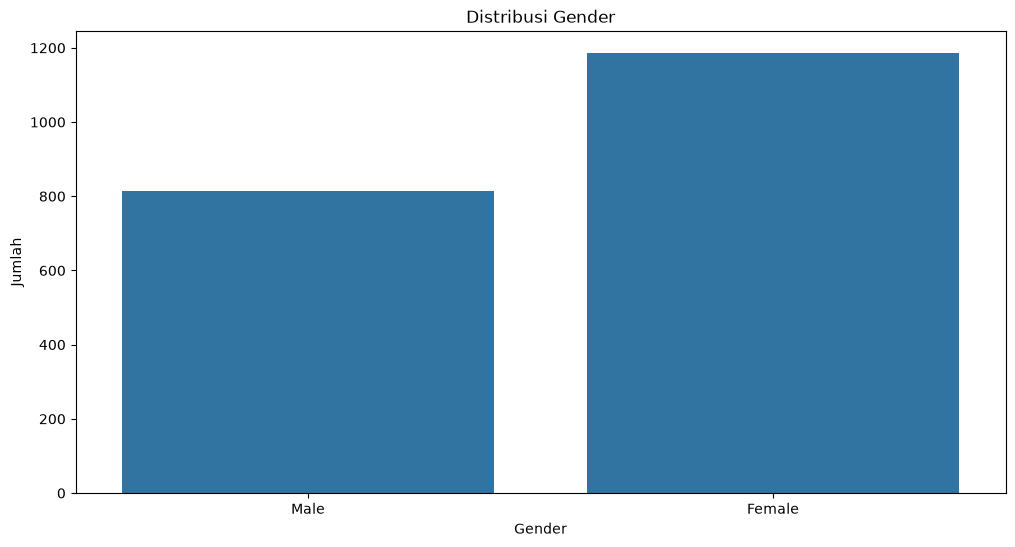

In [13]:
# Menampilkan visualisasi distribusi variabel numerik

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Gender",
)

plt.title("Distribusi Gender")
plt.xlabel("Gender")
plt.ylabel("Jumlah")
plt.show()

In [14]:
df["Profession"].value_counts(dropna=False)

Profession
Artist           612
Healthcare       339
Entertainment    234
Engineer         179
Doctor           161
Executive        153
Lawyer           142
Marketing         85
Homemaker         60
NaN               35
Name: count, dtype: int64

**Interpretasi distribusi Profession**

Kategori `Artist` mendominasi dengan 612 dari 2000 observasi (30,6%), jauh
di atas kategori lain. Kategori dengan frekuensi terkecil adalah `Homemaker`
sebesar 3,0%. Ketimpangan distribusi ini (imbalanced) perlu diperhatikan
karena jika `Profession` digunakan sebagai fitur clustering, kategori dominan
berpotensi tersebar ke berbagai cluster alih-alih membentuk cluster
tersendiri, bukan berarti atribut ini tidak layak digunakan.


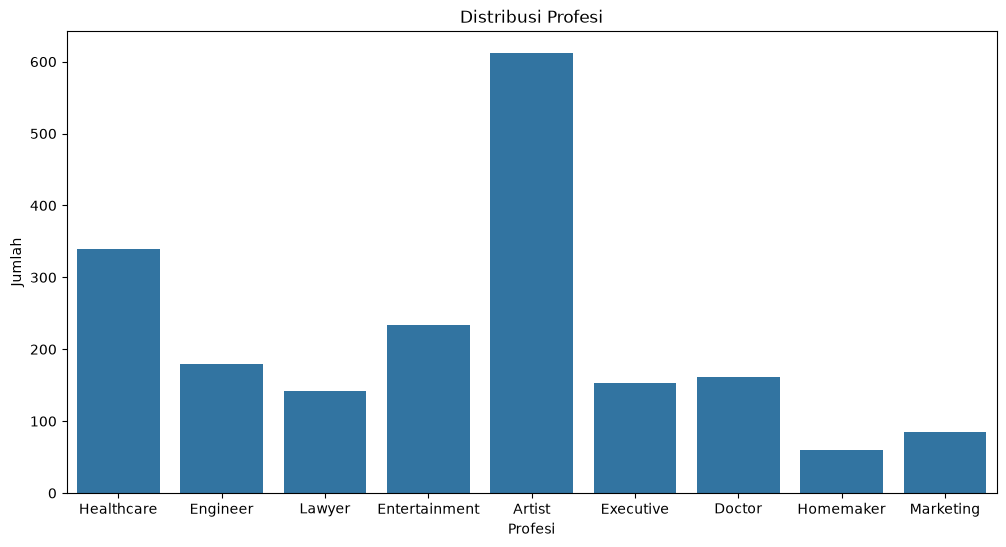

In [15]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Profession"
)

plt.title("Distribusi Profesi")
plt.xlabel("Profesi")
plt.ylabel("Jumlah")
plt.show()

### Analisis Distribusi Variabel Numerik

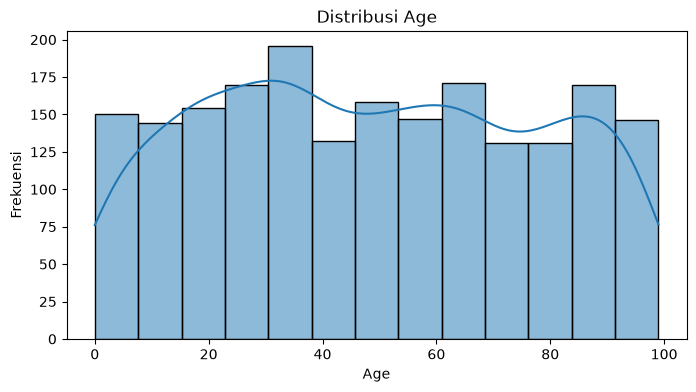

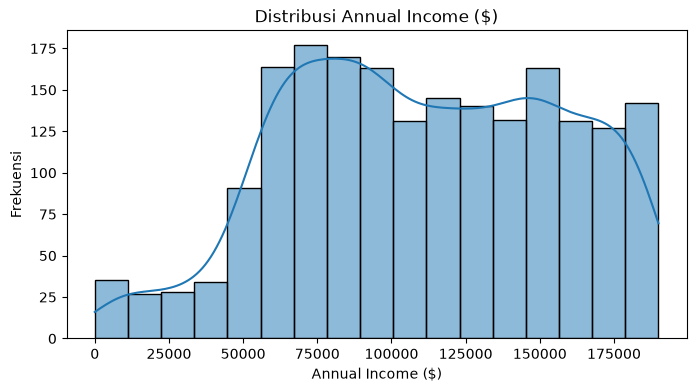

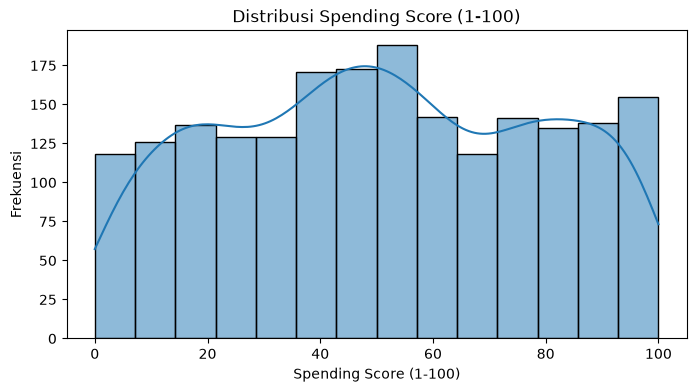

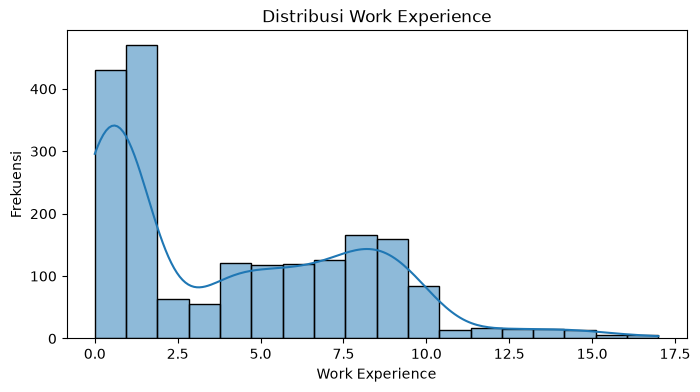

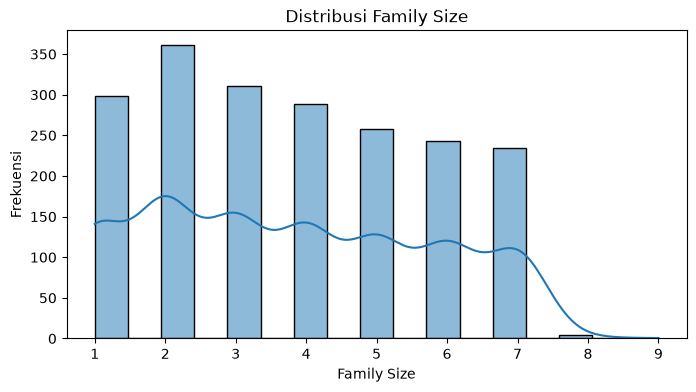

In [16]:
numeric_features = [
    'Age',
    'Annual Income ($)',
    'Spending Score (1-100)',
    'Work Experience',
    'Family Size'
]

for column in numeric_features:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(data=df, x=column, kde=True)
    
    plt.title(f'Distribusi {column}')
    plt.xlabel(column)
    plt.ylabel('Frekuensi')
    plt.show()

**Interpretasi distribusi variabel numerik**

- `Age`: distribusi relatif mendatar (mendekati uniform) pada rentang 0-99,
  tanpa skewness signifikan, konsisten dengan mean dan median yang berdekatan.
- `Annual Income ($)`: frekuensi rendah pada nilai kecil, meningkat tajam
  hingga sekitar 70.000, lalu relatif mendatar. Mayoritas pelanggan berada
  pada rentang pendapatan menengah ke atas.
- `Spending Score (1-100)`: relatif mendatar dan merata sepanjang rentang,
  mirip pola `Age`.
- `Work Experience`: menceng ke kanan, terkonsentrasi pada 0-2 tahun lalu
  menurun bertahap hingga 17 tahun, konsisten dengan mean lebih besar dari
  median pada statistik deskriptif.
- `Family Size`: menurun bertahap dari nilai 1 menuju 7, dengan frekuensi
  sangat kecil pada nilai 8 dan 9.


### Boxplot untuk Identifikasi Awal Outlier

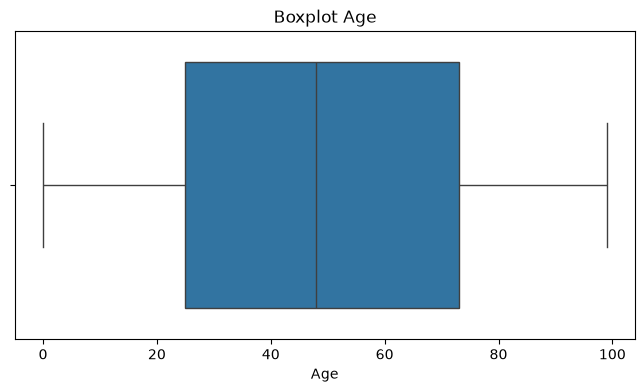

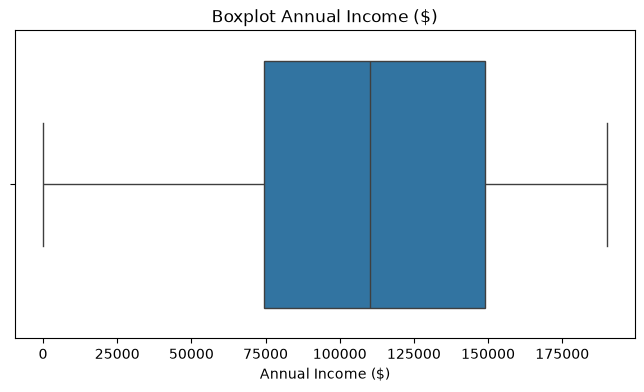

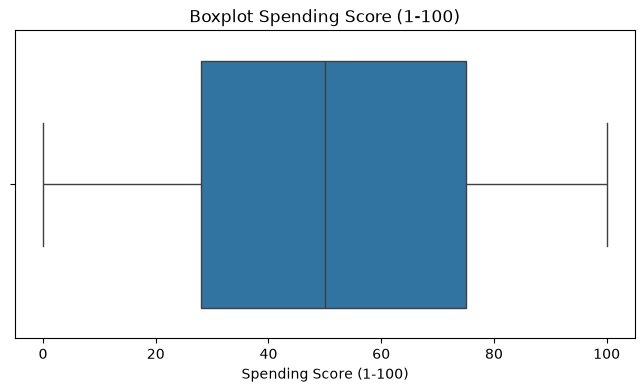

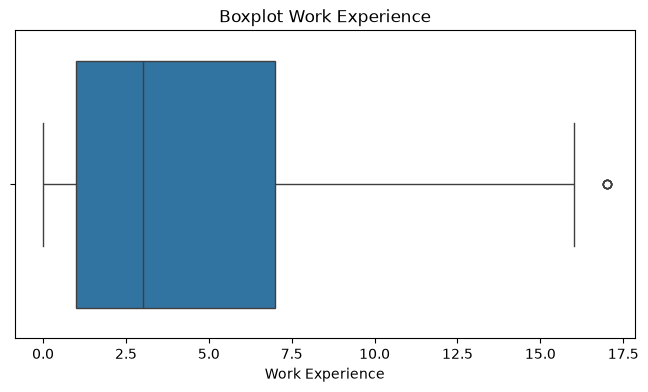

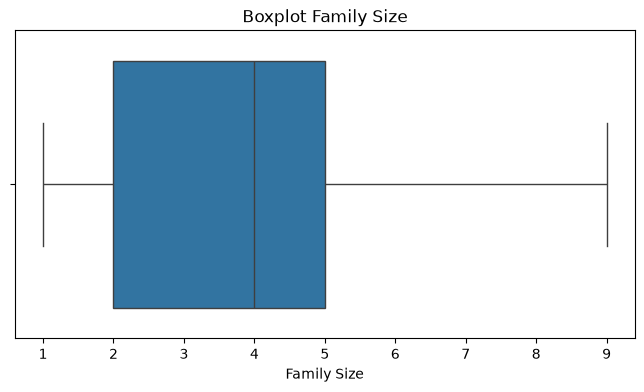

In [17]:
for col in numeric_features:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(data=df, x=col)
    
    plt.title(f'Boxplot {col}')
    plt.xlabel(col)
    plt.show()

### Pemeriksaan Nilai Tidak Wajar

In [18]:
# Menampilkan data dengan usia yang sangat rendah

age_low = df[df['Age'] <= 15]

display(age_low)

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
210,211,Female,1,57000,93,Engineer,1,2
211,212,Female,0,22000,92,Artist,2,1
228,229,Male,0,33000,64,Marketing,1,1
229,230,Male,15,94000,30,Healthcare,7,2
230,231,Female,6,93000,53,Lawyer,8,2
...,...,...,...,...,...,...,...,...
1974,1975,Female,14,153145,59,Healthcare,8,6
1979,1980,Male,0,165321,93,Doctor,8,1
1980,1981,Female,10,86925,76,Artist,7,2
1984,1985,Female,2,153622,51,Lawyer,6,6


In [19]:
age_high = df[df['Age'] >= 80]

display(age_high)

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
209,210,Female,80,39000,33,Engineer,9,4
212,213,Male,86,12000,70,Marketing,2,4
217,218,Female,83,35000,99,Doctor,8,2
221,222,Female,95,72000,51,Engineer,4,2
223,224,Female,93,93000,37,Healthcare,1,5
...,...,...,...,...,...,...,...,...
1991,1992,Female,97,129444,96,Entertainment,5,6
1992,1993,Male,94,181183,24,Marketing,9,3
1996,1997,Female,91,73158,32,Doctor,7,7
1997,1998,Male,87,90961,14,Healthcare,9,2


In [20]:
# Menampilkan data dengan Annual Income sangat rendah (mendekati atau sama dengan 0)

income_low = df[df['Annual Income ($)'] <= 1000]

display(income_low)
print('Jumlah observasi dengan Annual Income <= 1000:', income_low.shape[0])
print('Jumlah observasi dengan Annual Income = 0     :', (df['Annual Income ($)']==0).sum())


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
169,170,Male,32,0,63,Artist,2,2
246,247,Male,23,0,96,Doctor,1,3
272,273,Female,96,1000,76,Entertainment,0,3


Jumlah observasi dengan Annual Income <= 1000: 3
Jumlah observasi dengan Annual Income = 0     : 2


Pemeriksaan ini melengkapi pemeriksaan nilai tidak wajar pada `Age`, karena
`Annual Income ($)` juga memiliki nilai minimum 0 pada statistik deskriptif.
Nilai pendapatan tahunan yang sangat rendah atau sama dengan 0 perlu dicatat
sebagai temuan yang sama pentingnya dengan usia 0 tahun, untuk dipertimbangkan
lebih lanjut apakah merupakan kesalahan input data pada tahap Data Preparation.


### Pemeriksaan Outlier dengan IQR

In [21]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Jumlah Outlier': outliers.shape[0],
        'Percentase Outlier': (outliers.shape[0] / data.shape[0]) * 100
    }
    
outlier_results = []

for col in numeric_features:
    results = detect_outliers_iqr(df, col)
    results['Atribut'] = col
    outlier_results.append(results)
    
outlier_summary = pd.DataFrame(outlier_results)

outlier_summary = outlier_summary[
    [
        'Atribut',
        'Q1',
        'Q3',
        'IQR',
        'Lower Bound',
        'Upper Bound',
        'Jumlah Outlier',
        'Percentase Outlier'
    ]
]

display(outlier_summary)

,Atribut,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Percentase Outlier
0,Age,25.0,73.00,48.00,-47.000,145.000,0,0.00
1,Annual Income ($),74572.0,149092.75,74520.75,-37209.125,260873.875,0,0.00
2,Spending Score (1-100),28.0,75.00,47.00,-42.500,145.500,0,0.00
3,Work Experience,1.0,7.00,6.00,-8.000,16.000,5,0.25
4,Family Size,2.0,5.00,3.00,-2.500,9.500,0,0.00


**Interpretasi keterbatasan metode IQR**

Metode IQR standar hanya mendeteksi outlier pada `Work Experience` (5
observasi, 0,25%), sedangkan empat variabel lain menghasilkan 0 outlier.
Hal ini terjadi karena rentang IQR pada variabel tersebut cukup lebar
relatif terhadap rentang datanya (misalnya batas bawah `Age` mencapai -47,
jauh di luar rentang aktual 0-99), sehingga metode ini kurang sensitif untuk
mendeteksi anomali domain pada dataset dengan distribusi yang relatif merata.

Nilai `Age` = 0 pada 294 observasi yang ditemukan pada pemeriksaan nilai
tidak wajar sebelumnya tetap merupakan temuan penting, meskipun tidak
terdeteksi sebagai outlier statistik oleh IQR.


### Korelasi Variabel Numerik

In [22]:
correlation_matrix = df[numeric_features].corr()

display(correlation_matrix)

,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
Age,1.000000,0.021378,-0.041798,-0.014319,0.038254
Annual Income ($),0.021378,1.000000,0.023299,0.089136,0.093005
Spending Score (1-100),-0.041798,0.023299,1.000000,-0.028948,0.002232
Work Experience,-0.014319,0.089136,-0.028948,1.000000,0.011873
Family Size,0.038254,0.093005,0.002232,0.011873,1.000000


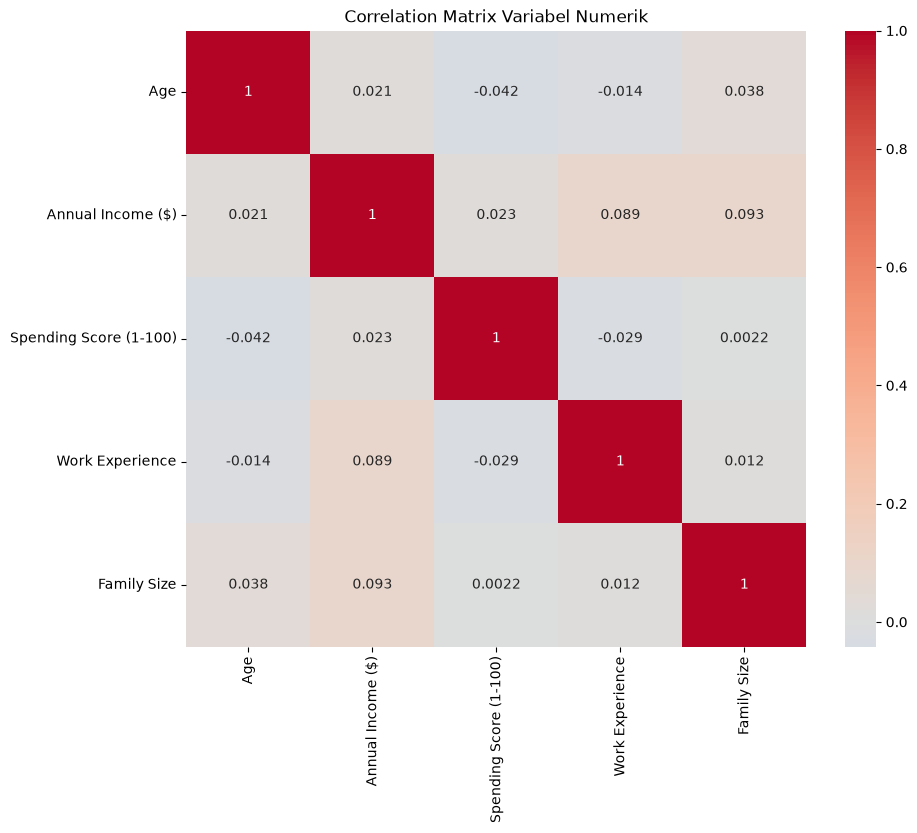

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix Variabel Numerik')
plt.show()

### Identifikasi Variabel Identifier

In [24]:
print('Jumlah nilai unik CustomerID:', df['CustomerID'].nunique())
print('jumlah observasi:', len(df))

if df['CustomerID'].nunique() == len(df):
    print('CustomerID bersifat unik untuk setiap pelanggan')

Jumlah nilai unik CustomerID: 2000
jumlah observasi: 2000
CustomerID bersifat unik untuk setiap pelanggan


### Identifikasi Identifier

`CustomerID` merupakan identifier unik untuk setiap pelanggan. Nilai tersebut
tidak merepresentasikan karakteristik pelanggan dan tidak memiliki makna
numerik dalam konteks pengukuran jarak antar pelanggan.

Oleh karena itu, `CustomerID` tidak dipertimbangkan sebagai fitur clustering.
Atribut ini tetap dipertahankan pada dataset asli untuk kebutuhan identifikasi
pelanggan dan interpretasi hasil cluster.

### Ringkasan Data Understanding

In [25]:
print(f"Jumlah observasi       : {df.shape[0]}")
print(f"Jumlah atribut         : {df.shape[1]}")
print(f"Missing value          : {df.isnull().sum().sum()}")
print(f"Baris duplikat         : {df.duplicated().sum()}")
print(f"CustomerID duplikat    : {df['CustomerID'].duplicated().sum()}")

print("\nTipe data:")
print(df.dtypes.value_counts())

print("\nAtribut dengan missing value:")
missing_cols = df.columns[df.isnull().any()].tolist()

if missing_cols:
    for col in missing_cols:
        print(f"- {col}: {df[col].isnull().sum()}")
else:
    print("- Tidak ada")

print("\nVariabel kategorikal:")
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    print(f"- {col}")

print("\nVariabel numerik:")
for col in numeric_features:
    print(f"- {col}")

Jumlah observasi       : 2000
Jumlah atribut         : 8
Missing value          : 35
Baris duplikat         : 0
CustomerID duplikat    : 0

Tipe data:
int64    6
str      2
Name: count, dtype: int64

Atribut dengan missing value:
- Profession: 35

Variabel kategorikal:
- Gender
- Profession

Variabel numerik:
- Age
- Annual Income ($)
- Spending Score (1-100)
- Work Experience
- Family Size


C:\Users\shsen\AppData\Local\Temp\ipykernel_2524\3452720642.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


### Kesimpulan Data Understanding (Naratif)

Dataset `Customers.csv` terdiri dari 2000 observasi dan 8 atribut. Tidak ditemukan
duplikasi baris maupun `CustomerID`, sedangkan missing value terdapat pada
`Profession` sebesar 1,75%.

Distribusi variabel numerik bervariasi, sedangkan `Profession` menunjukkan
distribusi kategori yang tidak merata. Korelasi antarvariabel numerik relatif
lemah, sehingga tidak ada satu pasangan variabel numerik yang secara jelas
mendominasi hubungan antarfitur.

Pemeriksaan berbasis domain menemukan **294 observasi dengan `Age <= 15`,
termasuk 24 observasi dengan `Age = 0`**, serta 3 observasi dengan
`Annual Income ($) <= 1000`. Temuan tersebut tidak otomatis dianggap sebagai
outlier statistik, sehingga keputusan penanganannya dibahas pada Data
Preparation dengan mempertimbangkan keterbatasan informasi sumber data.


# Data Preparation

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
path = "../dataset/Customers.csv"

df = pd.read_csv(path)

print("Shape dataset awal:", df.shape)
df.head()


Shape dataset awal: (2000, 8)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


### 3. Feature Selection (Data Selection)

Berdasarkan hasil Data Understanding, `CustomerID` merupakan identifier unik
untuk setiap pelanggan (2000 nilai unik untuk 2000 observasi) dan tidak
merepresentasikan karakteristik pelanggan, sehingga tidak digunakan sebagai
fitur clustering.

Ketujuh kolom lainnya (`Gender`, `Age`, `Annual Income ($)`,
`Spending Score (1-100)`, `Profession`, `Work Experience`, dan `Family Size`)
dipertahankan karena tersedia sebagai atribut karakteristik pelanggan yang
digunakan dalam segmentasi.

**Catatan metodologis:** relevansi fitur di sini bersifat eksploratif. Belum
ada variabel target atau outcome bisnis yang digunakan untuk membuktikan bahwa
setiap fitur memiliki kontribusi bisnis yang sama besar.


In [28]:
selected_features = [
    'Gender',
    'Age',
    'Annual Income ($)',
    'Spending Score (1-100)',
    'Profession',
    'Work Experience',
    'Family Size'
]

df_selected = df[selected_features].copy()

print("Shape sebelum data selection:", df.shape)
print("shape setelah data selection:", df_selected.shape)
print("kolom yang dikeluarkan:", [c for c in df.columns if c not in selected_features])

Shape sebelum data selection: (2000, 8)
shape setelah data selection: (2000, 7)
kolom yang dikeluarkan: ['CustomerID']


## Data Cleaning

Pemeriksaan dilakukan untuk memastikan tipe data sesuai, kategori konsisten,
dan tidak terdapat nilai numerik negatif pada atribut yang secara logis tidak
mengizinkannya seperti `Age`, `Annual Income ($)`, `Work Experience`, dan
`Family Size`.

Pemeriksaan ini dibedakan dari deteksi outlier. Nilai ekstrem belum tentu
merupakan kesalahan data, sehingga keputusan penghapusan dilakukan hanya jika
didukung oleh temuan kualitas data yang cukup jelas.


In [29]:
print(df_selected.dtypes)

print("Kategori unik Gender: ", df_selected['Gender'].unique().tolist())
print("Kategori unik Profession: ", df_selected['Profession'].unique().tolist())

print("\nJumlah nilai negatif perkolom numerik:")
numeric_cols_check=['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size']
for col in numeric_cols_check:
    print(f"{col}: {(df_selected[col] < 0).sum()}")

Gender                      str
Age                       int64
Annual Income ($)         int64
Spending Score (1-100)    int64
Profession                  str
Work Experience           int64
Family Size               int64
dtype: object
Kategori unik Gender:  ['Male', 'Female']
Kategori unik Profession:  ['Healthcare', 'Engineer', 'Lawyer', 'Entertainment', 'Artist', 'Executive', 'Doctor', 'Homemaker', 'Marketing', nan]

Jumlah nilai negatif perkolom numerik:
Age: 0
Annual Income ($): 0
Spending Score (1-100): 0
Work Experience: 0
Family Size: 0


**Analisis**

Tipe data seluruh kolom sudah sesuai dengan sifat datanya (numerik bertipe
`int64`, kategorikal bertipe object/string). Kategori pada `Gender` dan
`Profession` konsisten tanpa duplikasi penulisan (tidak ada variasi spasi
atau kapitalisasi). Tidak ditemukan nilai negatif pada kolom numerik mana
pun. Berdasarkan temuan ini, **tidak diperlukan proses Data Cleaning
tambahan** karena data sudah dalam format yang konsisten dan valid secara
tipe data.


# Missing Value Handling

In [30]:
missing_summary = pd.DataFrame({
    'Missing': df_selected.isnull().sum(),
    'Percentage': (df_selected.isnull().mean() * 100).round(2)
})

display(missing_summary)

,Missing,Percentage
Gender,0,0.00
Age,0,0.00
Annual Income ($),0,0.00
Spending Score (1-100),0,0.00
Profession,35,1.75
Work Experience,0,0.00
Family Size,0,0.00


**Analisis**

Missing value hanya ditemukan pada `Profession` sebanyak 35 observasi
(1,75%). Berdasarkan hasil Data Understanding, distribusi `Profession`
sudah timpang (kategori `Artist` mendominasi 30,6%). Melakukan imputasi
menggunakan modus berisiko memperbesar dominasi kategori yang sudah timpang
tanpa dasar informasi yang valid mengenai profesi pelanggan yang sebenarnya.

Karena proporsi missing value kecil (di bawah 5% dari total data) dan tidak
terdapat informasi lain dalam dataset yang dapat digunakan untuk menduga
`Profession` secara valid, baris dengan `Profession` kosong akan dihapus.
Keputusan ini menghindari risiko bias akibat imputasi kategori tanpa dasar
yang kuat.


In [31]:
print("Shape sebelum penanganan missing value:", df_selected.shape)

df_clean = df_selected.dropna(subset=['Profession']).reset_index(drop=True)

print("Shape setelah penanganan missing value :", df_clean.shape)
print("Sisa missing value:\n", df_clean.isnull().sum())


Shape sebelum penanganan missing value: (2000, 7)
Shape setelah penanganan missing value : (1965, 7)
Sisa missing value:
 Gender                    0
Age                       0
Annual Income ($)         0
Spending Score (1-100)    0
Profession                0
Work Experience           0
Family Size               0
dtype: int64


# Duplicate Handling

In [32]:
print("Jumlah baris duplikat: ", df_clean.duplicated().sum())

Jumlah baris duplikat:  0


**Analisis**

Tidak ditemukan baris duplikat pada dataset (konsisten dengan hasil Data
Understanding). **Tidak diperlukan proses penghapusan duplikat.**


### 7. Outlier Handling

Pada Data Understanding ditemukan dua jenis temuan nilai ekstrem:
1. deteksi IQR menemukan kandidat outlier terutama pada `Work Experience`; dan
2. pemeriksaan berbasis domain menemukan **294 observasi dengan `Age <= 15`,
   termasuk 24 observasi dengan `Age = 0`**, serta **3 observasi dengan
   `Annual Income ($) <= 1000`**.

Nilai tersebut **tidak dihapus** pada tahap ini karena notebook tidak memiliki
informasi eksternal untuk memastikan bahwa setiap nilai tersebut merupakan
kesalahan pencatatan. Dengan demikian, model mempertahankan data asli setelah
missing value `Profession` ditangani, dan kondisi tersebut dicatat sebagai
keterbatasan pada Evaluation.


In [33]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

numeric_features = ['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size']

outlier_report = []
for col in numeric_features:
    n_out, lb, ub = detect_outliers_iqr(df_clean, col)
    outlier_report.append({
        'Atribut': col,
        'Lower Bound': round(lb, 2),
        'Upper Bound': round(ub, 2),
        'Jumlah Outlier (IQR)': n_out,
        'Persentase (%)': round(n_out / len(df_clean) * 100, 2)
    })

display(pd.DataFrame(outlier_report))

print("Jumlah observasi Age <= 15                 :", (df_clean['Age'] <= 15).sum())
print("Jumlah observasi Age == 0                   :", (df_clean['Age'] == 0).sum())
print("Jumlah observasi Annual Income ($) <= 1000  :", (df_clean['Annual Income ($)'] <= 1000).sum())


,Atribut,Lower Bound,Upper Bound,Jumlah Outlier (IQR),Persentase (%)
0,Age,-47.0,145.0,0,0.00
1,Annual Income ($),-37767.5,261212.5,0,0.00
2,Spending Score (1-100),-42.5,145.5,0,0.00
3,Work Experience,-8.0,16.0,5,0.25
4,Family Size,-2.5,9.5,0,0.00


Jumlah observasi Age <= 15                 : 289
Jumlah observasi Age == 0                   : 23
Jumlah observasi Annual Income ($) <= 1000  : 3


**Analisis dan Keputusan**

Nilai `Age` = 0 dan `Annual Income ($)` mendekati 0 memang secara logis
janggal untuk profil pelanggan, namun keduanya **tidak dapat dipastikan**
sebagai kesalahan input data berdasarkan informasi yang tersedia. Beberapa
pertimbangan yang mendasari keputusan:

1. Proporsi `Age` = 0 cukup besar (sekitar 14-15% dari data). Jika nilai
   ini dihapus tanpa bukti kuat bahwa ini adalah kesalahan data, dataset
   akan kehilangan porsi data yang signifikan dan berpotensi menghilangkan
   segmen pelanggan tertentu secara tidak adil.
2. Metode IQR standar tidak menandai `Age`, `Annual Income ($)`, maupun
   `Spending Score (1-100)` sebagai outlier statistik, karena rentang IQR
   ketiga variabel ini cukup lebar relatif terhadap sebaran datanya.
3. Nilai pada `Work Experience` yang ditandai IQR (5 observasi, nilai
   mendekati batas atas rentang wajar pengalaman kerja) merupakan observasi
   valid, bukan kesalahan data, karena tidak melebihi batas logis yang
   mustahil (misalnya pengalaman kerja negatif atau melebihi usia).

Berdasarkan pertimbangan tersebut, **seluruh kandidat outlier/nilai tidak
wajar dipertahankan** dan tidak dilakukan penghapusan data pada tahap ini.
Temuan mengenai `Age` = 0 dan `Annual Income ($)` rendah tetap dicatat
sebagai keterbatasan data yang perlu disebutkan pada bagian keterbatasan
penelitian, karena verifikasi kebenaran nilai tersebut memerlukan akses ke
sumber data asli yang berada di luar cakupan proyek ini.


### 8. Encoding

Terdapat dua atribut kategorikal: `Gender` (2 kategori, nominal biner) dan
`Profession` (9 kategori, nominal tanpa urutan). Karena tidak ada hubungan
ordinal pada kedua atribut, digunakan:

- **Binary mapping** untuk `Gender` (2 kategori, cukup direpresentasikan
  dengan satu kolom 0/1, tidak perlu one-hot penuh).
- **One-Hot Encoding** untuk `Profession` (kategori nominal lebih dari 2,
  tanpa urutan, sehingga label encoding tidak sesuai karena akan
  menyiratkan urutan/jarak numerik yang tidak ada maknanya).

Encoding tidak dilakukan pada `CustomerID` karena sudah dikeluarkan pada
tahap Feature Selection.


In [34]:
df_encoded = df_clean.copy()

df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 0, 'Female': 1})

df_encoded = pd.get_dummies(
    df_encoded,
    columns=['Profession'],
    prefix='Profession',
    drop_first=True
)

print("Shape sebelum encoding: ", df_clean.shape)
print("Shape setelah encoding: ",df_encoded.shape)

df_encoded.head()

Shape sebelum encoding:  (1965, 7)
Shape setelah encoding:  (1965, 14)


,Gender,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,0,19,15000,39,1,4,False,False,False,False,True,False,False,False
1,0,21,35000,81,3,3,False,True,False,False,False,False,False,False
2,1,20,86000,6,1,1,False,True,False,False,False,False,False,False
3,1,23,59000,77,0,2,False,False,False,False,False,False,True,False
4,1,31,38000,40,2,6,False,False,True,False,False,False,False,False


## Analisis

Setelah encoding, jumlah kolom bertambah dari 7 menjadi 14 kolom. `Gender` diubah menjadi satu fitur numerik, sedangkan `Profession` menghasilkan 8 dummy variable karena menggunakan `drop_first=True`. Dengan demikian, seluruh fitur pada `df_encoded` sudah berbentuk numerik dan siap untuk proses standardisasi.


# Scaling / Standarization

Fitur numerik pada dataset memiliki skala yang sangat berbeda (misalnya
`Annual Income ($)` berkisar 0 hingga ratusan ribu, sedangkan `Family Size`
hanya berkisar 1 hingga 9). Karena algoritma clustering berbasis jarak
seperti K-Means sensitif terhadap skala fitur, standardisasi diperlukan
agar setiap fitur memberikan kontribusi yang seimbang terhadap perhitungan
jarak antar observasi. `StandardScaler` digunakan untuk mengubah setiap
fitur menjadi memiliki mean 0 dan standar deviasi 1.

Karena tidak terdapat train-test split pada proyek unsupervised ini,
`scaler` di-*fit* pada keseluruhan `df_encoded`. Ini bukan merupakan data
leakage dalam pengertian supervised learning (tidak ada informasi target
yang bocor ke fitur), namun objek `scaler` tetap disimpan agar transformasi
yang identik dapat diterapkan kembali apabila terdapat data pelanggan baru
di kemudian hari.

In [35]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(X_scaled, columns = df_encoded.columns)

print(df_scaled.shape)
df_scaled.head()

(1965, 14)


,Gender,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,-1.208025,-1.052345,-2.086675,-0.431850,-0.787837,0.123358,-0.298741,-0.316582,-0.367671,-0.290581,2.190082,-0.177471,-0.279094,-0.212633
1,-1.208025,-0.981941,-1.650205,1.069755,-0.278342,-0.384815,-0.298741,3.158742,-0.367671,-0.290581,-0.456604,-0.177471,-0.279094,-0.212633
2,0.827798,-1.017143,-0.537207,-1.611684,-0.787837,-1.401161,-0.298741,3.158742,-0.367671,-0.290581,-0.456604,-0.177471,-0.279094,-0.212633
3,0.827798,-0.911538,-1.126441,0.926745,-1.042584,-0.892988,-0.298741,-0.316582,-0.367671,-0.290581,-0.456604,-0.177471,3.583019,-0.212633
4,0.827798,-0.629924,-1.584734,-0.396098,-0.533089,1.139704,-0.298741,-0.316582,2.719823,-0.290581,-0.456604,-0.177471,-0.279094,-0.212633


**Analisis**

Dataset akhir (`df_scaled`) tidak memiliki missing value maupun duplikasi,
seluruh kolom bertipe numerik, dan setiap fitur telah distandardisasi
(mean mendekati 0 dan standar deviasi mendekati 1). Dataset ini sudah siap
digunakan pada tahap Modeling (clustering) berikutnya.


### Kesimpulan Data Preparation

Tahap Data Preparation pada proyek ini terdiri dari: pemilihan fitur
(mengeluarkan `CustomerID` sebagai identifier), penghapusan 35 baris
dengan `Profession` kosong, encoding `Gender` (binary) dan `Profession`
(one-hot), serta standardisasi seluruh fitur numerik. Data Cleaning
tambahan, penghapusan duplikat, penghapusan outlier, dan train-test split
tidak dilakukan karena berdasarkan temuan aktual Data Understanding,
tahapan tersebut memang tidak diperlukan atau tidak sesuai dengan sifat
unsupervised dari proyek ini. Dataset akhir siap digunakan pada tahap
Modeling clustering.


---
# Modeling

Tahap Modeling merupakan proses pembentukan kelompok pelanggan menggunakan
algoritma clustering. Karena dataset merupakan data unsupervised learning,
tidak terdapat variabel target dan tidak dilakukan pembagian data menjadi
training dan testing.

Pada tahap ini dilakukan beberapa proses, yaitu:
1. Menentukan jumlah cluster yang optimal.
2. Membandingkan kualitas beberapa alternatif jumlah cluster.
3. Membentuk model K-Means dengan jumlah cluster terpilih.
4. Melakukan fitting model pada seluruh data hasil Data Preparation.
5. Mengevaluasi hasil clustering menggunakan metrik evaluasi internal.
6. Menganalisis karakteristik dan distribusi setiap cluster.

Tahap Modeling dimulai setelah seluruh data berhasil dipersiapkan dalam
bentuk numerik dan telah distandardisasi. Karena tujuan penelitian adalah
mengelompokkan pelanggan berdasarkan kemiripan karakteristik tanpa adanya
label kelas, pendekatan clustering digunakan.

K-Means dipilih sebagai algoritma utama karena data yang digunakan pada tahap
modeling telah berbentuk numerik dan terstandardisasi, sehingga perhitungan
jarak antarobservasi dapat dilakukan secara konsisten.

In [36]:
# import library yang dibutuhkan 
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import seaborn as sns

**Analisis**

Library yang digunakan pada tahap Modeling mencakup `KMeans` untuk membangun
model clustering dan beberapa metrik evaluasi internal, yaitu Silhouette
Score, Calinski-Harabasz Index, dan Davies-Bouldin Index.

Ketiga metrik digunakan secara bersamaan agar pemilihan jumlah cluster tidak
hanya bergantung pada satu indikator.

In [37]:
X = df_scaled.values

k_range = range(2, 22)  # Menggunakan range dari 2 hingga 21 untuk jumlah cluster

inertia = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))
    calinski_scores.append(calinski_harabasz_score(X, labels))
    davies_scores.append(davies_bouldin_score(X, labels))
evaluation_metrics = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertia,
    'silhouette_score': silhouette_scores,
    'calinski_harabasz_score': calinski_scores,
    'davies_bouldin_score': davies_scores
})

display(evaluation_metrics)

,K,Inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,2,25421.837863,0.152941,161.241776,1.605430
1,3,23274.848750,0.137839,178.505279,1.758227
2,4,21207.754624,0.137598,194.248180,1.745861
3,5,19202.449745,0.188017,211.988558,1.800621
4,6,17257.798717,0.216724,232.753466,1.665768
5,7,15336.245767,0.245175,259.040045,1.563813
6,8,13347.200178,0.266751,296.655038,1.382503
7,9,11722.293224,0.281879,329.295150,1.351038
8,10,11124.002831,0.246391,319.974992,1.383708
9,11,10786.470684,0.226214,302.951514,1.396312


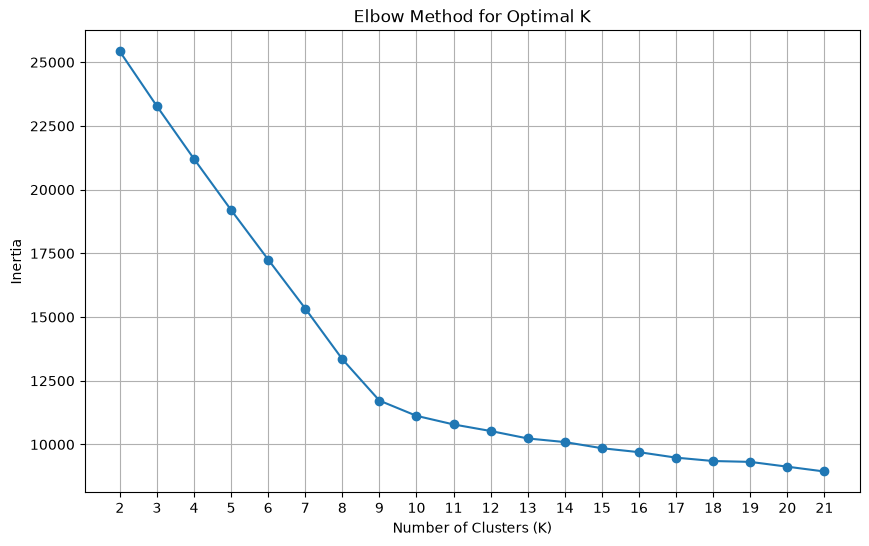

In [38]:
# Elbow Method

plt.figure(figsize=(10, 6))
plt.plot(evaluation_metrics['K'], evaluation_metrics['Inertia'], marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.xticks(list(k_range))
plt.show()

**Analisis**

Elbow Method digunakan untuk melihat perubahan nilai inertia ketika jumlah
cluster bertambah. Inertia menunjukkan total jarak kuadrat setiap observasi
terhadap centroid cluster-nya.

Nilai inertia akan selalu menurun ketika jumlah cluster bertambah, sehingga
yang diperhatikan bukan sekadar nilai inertia terkecil, tetapi perubahan
penurunannya. Grafik digunakan untuk mengidentifikasi titik ketika
penambahan jumlah cluster mulai memberikan pengurangan inertia yang semakin
kecil.

Berdasarkan grafik, kandidat jumlah cluster kemudian dikonfirmasi dengan
Silhouette Score dan metrik evaluasi internal lainnya agar keputusan tidak
hanya berdasarkan bentuk grafik Elbow.

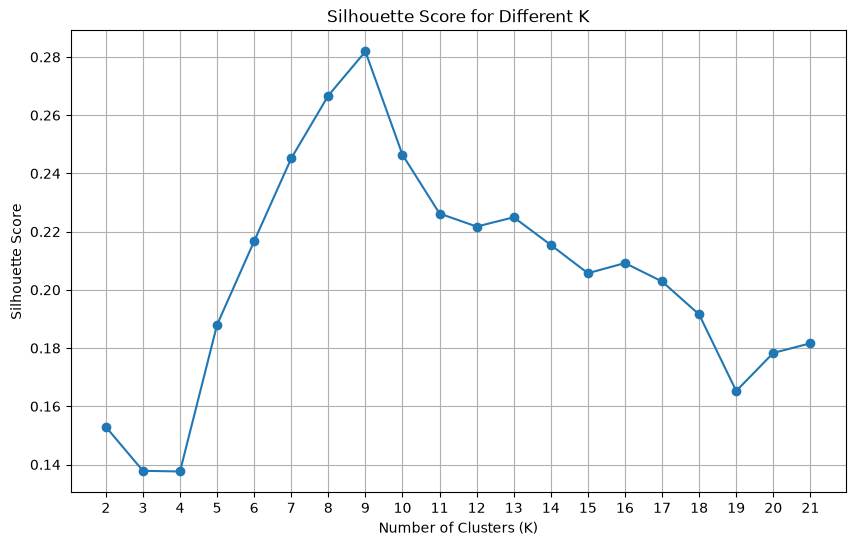

In [39]:
# Silhouette Score

plt.figure(figsize=(10, 6))

plt.plot(
    list(k_range),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K')
plt.grid(True)
plt.xticks(list(k_range))
plt.show()

**Analisis**

Silhouette Score mengukur seberapa baik sebuah observasi berada di dalam
cluster dibandingkan dengan cluster lainnya. Nilai yang semakin tinggi
menunjukkan bahwa observasi cenderung lebih dekat dengan cluster-nya sendiri
dan lebih jauh dari cluster lain.

Pada pengujian ini, nilai Silhouette Score meningkat dari K=2 hingga mencapai
nilai tertinggi pada K=8, yaitu sekitar 0,294. Setelah K=8, nilai tersebut
menurun menjadi sekitar 0,282 pada K=9 dan sekitar 0,246 pada K=10.

Dengan demikian, berdasarkan Silhouette Score, K=8 menjadi kandidat utama
jumlah cluster karena menghasilkan pemisahan cluster terbaik dalam rentang
pengujian.

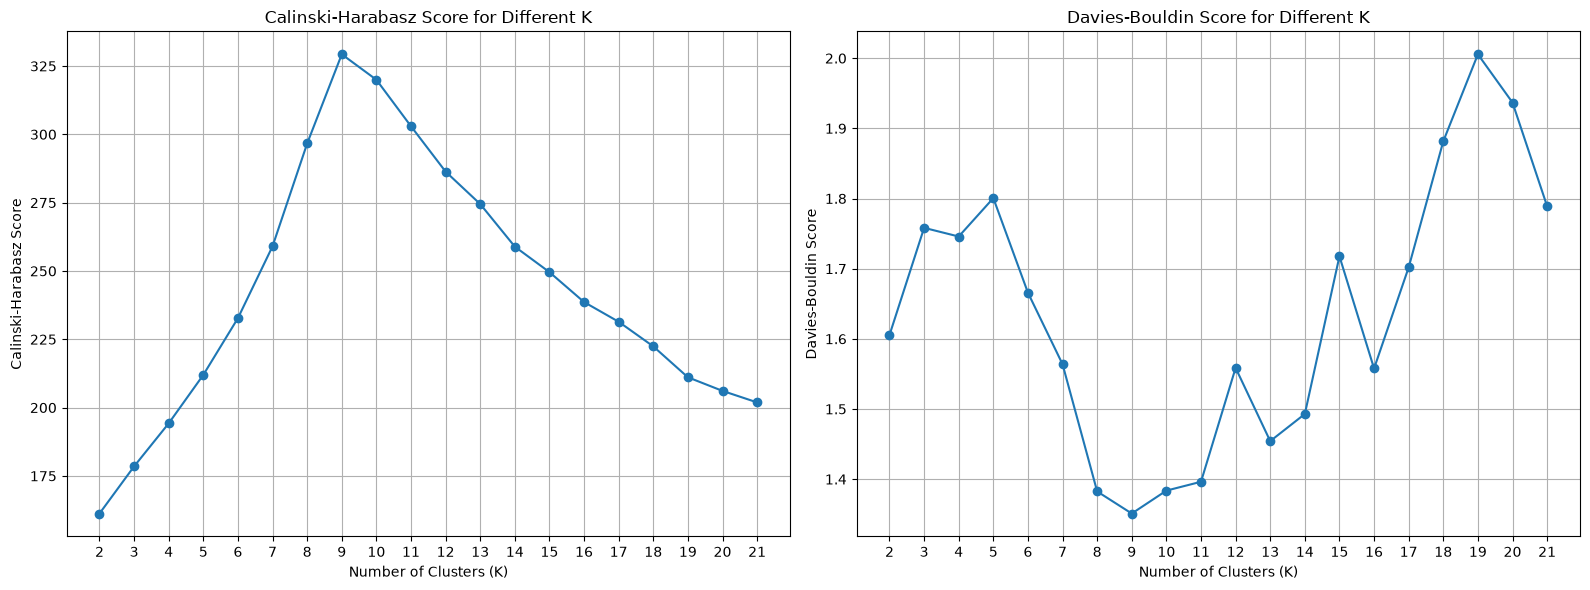

In [40]:
# Validasi dengan Calinski-Harabasz dan Davies-Bouldin

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(list(k_range), calinski_scores, marker='o')

axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Calinski-Harabasz Score') 
axes[0].set_title('Calinski-Harabasz Score for Different K')
axes[0].grid(True)
axes[0].set_xticks(list(k_range))

# Davies-Bouldin Score
axes[1].plot(list(k_range), davies_scores, marker='o')

axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score for Different K')
axes[1].grid(True)
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()


**Analisis**

Calinski-Harabasz Index menunjukkan kualitas cluster berdasarkan hubungan
antara penyebaran antar-cluster dan penyebaran di dalam cluster. Nilai yang
lebih tinggi menunjukkan struktur cluster yang lebih baik.

Pada hasil pengujian, nilai Calinski-Harabasz meningkat hingga K=9.
Namun, peningkatan dari K=8 ke K=9 perlu dipertimbangkan bersama dengan metrik
lain karena penambahan cluster tidak selalu menghasilkan segmentasi yang
lebih mudah diinterpretasikan.

Davies-Bouldin Index memiliki prinsip yang berbeda, yaitu semakin rendah
nilainya menunjukkan cluster yang semakin terpisah dan semakin kompak.
Nilai terendah pada pengujian diperoleh pada K=8.

Dengan mempertimbangkan ketiga metrik tersebut, K=8 memberikan kombinasi
hasil yang konsisten, yaitu Silhouette Score tertinggi, Davies-Bouldin Index
terendah, serta nilai Calinski-Harabasz yang tinggi. Oleh karena itu, K=8
dipilih sebagai jumlah cluster pada model akhir.

---
## Penentuan Jumlah Cluster

Pengujian jumlah cluster dilakukan pada rentang **K=2 hingga K=21** dengan
mempertimbangkan Elbow Method, Silhouette Score, Calinski-Harabasz Index, dan
Davies-Bouldin Index.

Pada hasil pengujian aktual, **K=8** memberikan Silhouette Score tertinggi
(sekitar **0,294**) dan Davies-Bouldin Index terendah (sekitar **1,304**).
K=9 memberikan Calinski-Harabasz Index yang lebih tinggi, tetapi tidak
mengungguli K=8 pada Silhouette Score maupun Davies-Bouldin Index.

Dengan demikian, K=8 dipilih berdasarkan kombinasi metrik internal. Setelah
model final difit ulang dengan konfigurasi yang sama, metrik evaluasi akhir
dihitung kembali pada tahap Evaluation untuk memastikan konsistensi antara
pemilihan K dan model final.


In [41]:
# Membentuk Model K-Means Final

optimal_k = 8

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans_final.fit_predict(X)

print("Jumlah cluster:", optimal_k)
print("Jumlah observasi:", len(cluster_labels))


Jumlah cluster: 8
Jumlah observasi: 1965


**Analisis**

Model K-Means final menggunakan **K=8**, `random_state=42`, dan `n_init=20`. Konfigurasi ini konsisten dengan hasil penentuan jumlah cluster dan memberikan beberapa inisialisasi centroid untuk mengurangi ketergantungan pada satu titik awal.

Model kemudian difit menggunakan seluruh 1.965 observasi dan **14 fitur** hasil Data Preparation. Karena clustering bersifat unsupervised dan tidak memiliki target, seluruh data digunakan dalam pembentukan cluster.


In [42]:
# Fitting pada Seluruh Data

kmeans_final.fit(X)

final_labels = kmeans_final.labels_

print("Model berhasil di-fit pada seluruh data.")
print("Jumlah data yang digunakan: ", X.shape[0])
print("Jumlah fitur yang digunakan: ", X.shape[1])

Model berhasil di-fit pada seluruh data.
Jumlah data yang digunakan:  1965
Jumlah fitur yang digunakan:  14


**Analisis**

Berbeda dengan supervised learning, clustering tidak menggunakan variabel target sehingga tidak diperlukan pembagian training dan testing. Model K-Means final difit menggunakan seluruh **1.965 observasi dan 14 fitur** hasil Data Preparation.

Penggunaan seluruh data memungkinkan centroid dibentuk berdasarkan seluruh karakteristik pelanggan yang tersedia.


In [43]:
# Menyimpan Label Cluster

df_results = df_clean.copy()

df_results['Cluster'] = final_labels

df_results.head()

,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Cluster
0,Male,19,15000,39,Healthcare,1,4,1
1,Male,21,35000,81,Engineer,3,3,7
2,Female,20,86000,6,Engineer,1,1,7
3,Female,23,59000,77,Lawyer,0,2,0
4,Female,31,38000,40,Entertainment,2,6,6


**Analisis**

Label cluster hasil K-Means ditambahkan kembali ke dataset yang telah
dibersihkan. Dengan demikian, setiap pelanggan memiliki informasi cluster
yang dapat digunakan untuk melakukan analisis karakteristik dan segmentasi.

Data hasil clustering tetap menggunakan atribut asli sebelum encoding agar
interpretasi cluster lebih mudah dilakukan.

In [44]:
# Evaluasi Akhir Model

final_labels = kmeans_final.labels_

final_silhouette = silhouette_score(X, final_labels)
final_calinski = calinski_harabasz_score(X, final_labels)
final_davies = davies_bouldin_score(X, final_labels)

final_evaluation = pd.DataFrame({
    'Metric': [
        'Silhouette Score',
        'Calinski-Harabasz Index',
        'Davies-Bouldin Index'
    ],
    'Value': [
        final_silhouette,
        final_calinski,
        final_davies
    ]
})

display(final_evaluation.round(4))


,Metric,Value
0,Silhouette Score,0.2940
1,Calinski-Harabasz Index,300.4657
2,Davies-Bouldin Index,1.3035


**Analisis Evaluasi Akhir**

Setelah model final K=8 dijalankan kembali dengan `random_state=42` dan `n_init=20`, diperoleh:

- **Silhouette Score = 0.2940**
- **Calinski-Harabasz Index = 300.4657**
- **Davies-Bouldin Index = 1.3035**

Silhouette Score bernilai positif, sehingga secara umum observasi lebih dekat dengan cluster-nya sendiri daripada cluster lain, tetapi nilainya masih menunjukkan adanya kedekatan antar-cluster. Calinski-Harabasz memberikan ukuran relatif mengenai pemisahan antar-cluster dibandingkan penyebaran di dalam cluster, sedangkan Davies-Bouldin yang lebih rendah menunjukkan cluster yang lebih kompak dan lebih terpisah.

Nilai metrik perlu dibaca sebagai evaluasi internal, bukan sebagai bukti bahwa segmentasi sudah sempurna. Oleh karena itu, evaluasi dilanjutkan dengan pemeriksaan ukuran cluster, karakteristik setiap cluster, visualisasi PCA, dan stabilitas terhadap perubahan `random_state`.


In [45]:
# Distribusi Jumlah Anggota Cluster

cluster_distribution = (
    df_results['Cluster']
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_distribution.columns = ['Cluster','Jumlah Anggota']

cluster_distribution['Persentase (%)'] = (
    cluster_distribution['Jumlah Anggota']
    / len(df_results) * 100
).round(2)

display(cluster_distribution)

,Cluster,Jumlah Anggota,Persentase (%)
0,0,142,7.23
1,1,951,48.40
2,2,161,8.19
3,3,153,7.79
4,4,85,4.33
5,5,60,3.05
6,6,234,11.91
7,7,179,9.11


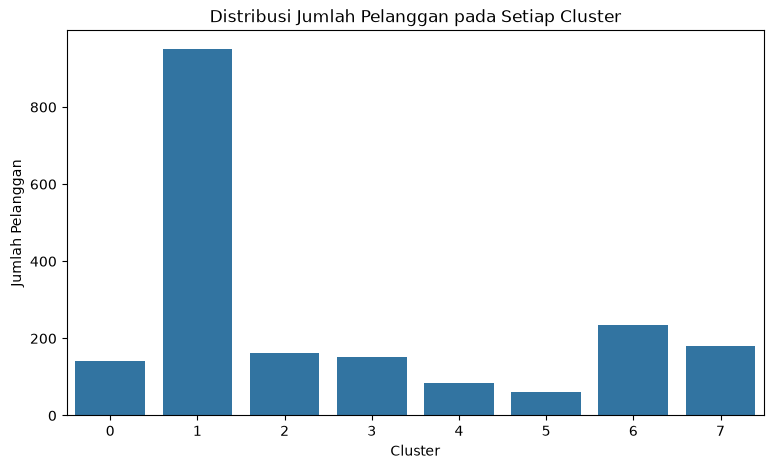

In [46]:
# Visualisasi 

plt.figure(figsize=(9, 5))

sns.barplot(
    data=cluster_distribution,
    x='Cluster',
    y='Jumlah Anggota'
)

plt.title('Distribusi Jumlah Pelanggan pada Setiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Pelanggan')

plt.show()

**Analisis**

Distribusi ukuran cluster digunakan untuk memastikan bahwa hasil K-Means tidak hanya membentuk satu kelompok yang sangat dominan tanpa konteks. Perbedaan ukuran cluster merupakan hal yang mungkin terjadi secara alami pada data pelanggan.

Namun, apabila terdapat cluster yang sangat kecil atau satu cluster jauh lebih dominan, hasil tersebut perlu diperiksa bersama profil karakteristik dan silhouette per cluster. Dengan demikian, ukuran cluster tidak dinilai hanya dari keseimbangannya, tetapi dari apakah kelompok tersebut memiliki karakteristik yang dapat dijelaskan.


In [47]:
# Profiling Cluster

numeric_profile = (
    df_results
    .groupby('Cluster')[
        [
            'Age',
            'Annual Income ($)',
            'Spending Score (1-100)',
            'Work Experience',
            'Family Size'
            ]
    ]
    .mean()
    .round(2)
)

display(numeric_profile)

,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
Cluster,,,,,
0,47.75,110995.84,48.86,3.53,3.62
1,48.59,110130.25,51.91,4.14,3.74
2,46.62,111573.22,51.90,4.30,3.67
3,46.60,113770.13,49.90,4.25,3.97
4,45.82,107994.21,48.72,4.31,3.73
5,45.37,108758.62,46.38,6.13,4.05
6,51.16,110650.33,52.94,3.50,3.89
7,55.09,111161.24,48.97,3.96,3.58


**Analisis**

Profil numerik digunakan untuk mengetahui karakteristik rata-rata pelanggan
pada setiap cluster. Variabel yang dianalisis meliputi usia, pendapatan
tahunan, spending score, pengalaman kerja, dan ukuran keluarga.

Perbedaan nilai rata-rata antar-cluster dapat digunakan untuk memahami
karakteristik utama masing-masing segmentasi pelanggan. Interpretasi tidak
hanya didasarkan pada ukuran cluster, tetapi juga pada kombinasi beberapa
atribut pelanggan.

In [48]:
# Profil Profession

profession_profile = pd.crosstab(
    df_results['Cluster'],
    df_results['Profession'],
    normalize='index'
) * 100

display(profession_profile.round(2))

Profession,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
Cluster,,,,,,,,,
0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,100.0,0.0
1,64.35,0.0,0.0,0.0,0.0,35.65,0.0,0.0,0.0
2,0.00,100.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
3,0.00,0.0,0.0,0.0,100.0,0.00,0.0,0.0,0.0
4,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,100.0
5,0.00,0.0,0.0,0.0,0.0,0.00,100.0,0.0,0.0
6,0.00,0.0,0.0,100.0,0.0,0.00,0.0,0.0,0.0
7,0.00,0.0,100.0,0.0,0.0,0.00,0.0,0.0,0.0


**Analisis**

Distribusi profesi pada setiap cluster digunakan untuk mengetahui apakah
terdapat karakteristik profesi tertentu yang lebih dominan pada suatu
cluster.

Persentase dihitung berdasarkan masing-masing cluster sehingga nilai pada
setiap baris menunjukkan komposisi profesi dalam cluster tersebut. Informasi
ini membantu menjelaskan hasil clustering menggunakan atribut kategorikal
yang sebelumnya telah melalui proses One-Hot Encoding.

In [49]:
# Gender Profil

gender_profile = pd.crosstab(
    df_results['Cluster'],
    df_results['Gender'],
    normalize='index'
)

display(gender_profile)

Gender,Female,Male
Cluster,,
0,0.605634,0.394366
1,0.605678,0.394322
2,0.552795,0.447205
3,0.568627,0.431373
4,0.623529,0.376471
5,0.650000,0.350000
6,0.568376,0.431624
7,0.575419,0.424581


**Analisis**

Distribusi Gender digunakan sebagai informasi tambahan untuk memahami
komposisi masing-masing cluster. Nilai yang ditampilkan merupakan persentase
gender di dalam setiap cluster sehingga dapat dibandingkan antar kelompok.

Variabel ini digunakan untuk memperkaya interpretasi hasil clustering dan
tidak digunakan sebagai dasar tunggal dalam memberikan karakterisasi cluster.

total variance yang dijelaskan:  17.04 %


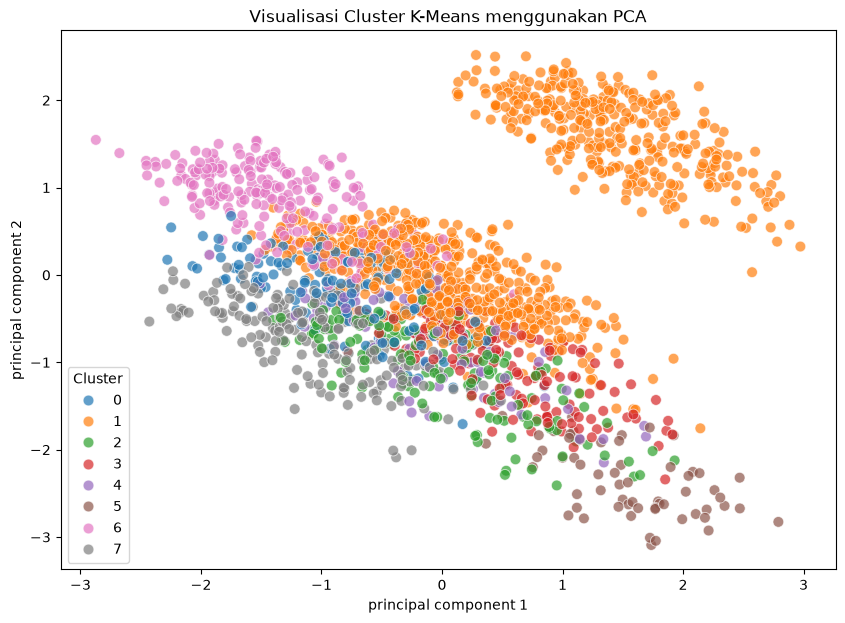

In [50]:
# Visualisasi PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': final_labels,
})

print(
    "total variance yang dijelaskan: ",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    s=60,
    alpha=0.7
)

plt.title("Visualisasi Cluster K-Means menggunakan PCA")
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(title='Cluster')

plt.show()


**Analisis**

PCA digunakan hanya untuk membantu visualisasi data berdimensi tinggi menjadi dua dimensi. Model K-Means tetap menggunakan seluruh 14 fitur hasil standardisasi.

Dua komponen utama menjelaskan sebagian dari variasi data sehingga visualisasi PCA tidak dapat digunakan untuk menyimpulkan seluruh struktur cluster. Jika titik antar-cluster terlihat tumpang tindih, hal tersebut menjadi indikasi visual bahwa sebagian pelanggan memiliki karakteristik yang relatif mirip.


In [51]:
seeds = [0, 21, 42, 99]

stability_results = []

for seed in seeds:
    model = KMeans(
        n_clusters=8,
        random_state=seed,
        n_init=20
    )

    labels = model.fit_predict(X)

    stability_results.append({
        'Random State': seed,
        'Inertia': model.inertia_,
        'Silhouette Score': silhouette_score(X, labels),
        'Calinski-Harabasz Index': calinski_harabasz_score(X, labels),
        'Davies-Bouldin Index': davies_bouldin_score(X, labels)
    })

stability_df = pd.DataFrame(stability_results)

display(stability_df.round(4))


,Random State,Inertia,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,0,13420.8642,0.2672,293.4923,1.4275
1,21,13406.1601,0.2660,294.1208,1.4154
2,42,13259.5134,0.2940,300.4657,1.3035
3,99,13420.8642,0.2672,293.4923,1.4275


**Analisis**

Uji stabilitas dilakukan dengan beberapa nilai `random_state` pada konfigurasi K=8 dan `n_init=20`. Tujuannya adalah melihat seberapa konsisten kualitas clustering ketika inisialisasi model berubah.

Perbedaan nilai metrik dan ukuran cluster antar-seed menunjukkan bahwa K-Means masih memiliki sensitivitas terhadap inisialisasi. Karena itu, `n_init=20` digunakan untuk mencari solusi dengan objective clustering yang lebih baik pada setiap seed, tetapi hasil akhir tetap perlu dibaca sebagai satu solusi clustering pada dataset ini.


---
## Kesimpulan Tahap Modeling

Berdasarkan pengujian K=2 hingga K=21, K=8 dipilih sebagai konfigurasi model akhir berdasarkan kombinasi metrik internal. Pada tabel pengujian, K=8 menghasilkan Silhouette Score tertinggi sebesar 0,2668 dan Davies-Bouldin Index terendah sebesar 1,3825. K=9 memiliki Calinski-Harabasz Index lebih tinggi, tetapi tidak memberikan hasil yang lebih baik pada dua metrik tersebut.

Model akhir kemudian dibentuk dengan K=8, `random_state=42`, dan `n_init=20`, menggunakan seluruh 1.965 observasi dan 14 fitur hasil standardisasi.

Tahap Evaluation berikutnya digunakan untuk memeriksa kualitas struktur cluster secara lebih mendalam, distribusi ukuran cluster, karakteristik masing-masing cluster, visualisasi, dan stabilitas model.


---
# Evaluation

Tahap Evaluation dalam CRISP-DM digunakan untuk menilai apakah hasil clustering yang terbentuk sudah cukup bermakna untuk menjawab tujuan segmentasi pelanggan. Evaluasi dilakukan dari beberapa sudut: kualitas internal cluster, distribusi anggota, kualitas masing-masing cluster, interpretasi karakteristik, visualisasi, dan stabilitas model.


## 1. Evaluasi Kualitas Internal Model


In [52]:
# Menghitung kembali metrik evaluasi untuk model final
final_labels = kmeans_final.labels_

final_silhouette = silhouette_score(X, final_labels)
final_calinski = calinski_harabasz_score(X, final_labels)
final_davies = davies_bouldin_score(X, final_labels)

evaluation_summary = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Index', 'Davies-Bouldin Index'],
    'Value': [final_silhouette, final_calinski, final_davies]
})

display(evaluation_summary.round(4))


,Metric,Value
0,Silhouette Score,0.2940
1,Calinski-Harabasz Index,300.4657
2,Davies-Bouldin Index,1.3035


**Analisis**

Evaluasi akhir model K=8 menghasilkan Silhouette Score **0.2940**, Calinski-Harabasz Index **300.4657**, dan Davies-Bouldin Index **1.3035**. Ketiga metrik digunakan bersama karena masing-masing mengukur aspek yang berbeda dari struktur cluster.

Silhouette Score yang positif menunjukkan bahwa secara rata-rata pelanggan lebih dekat dengan cluster-nya sendiri dibandingkan cluster lain, tetapi nilainya belum menunjukkan pemisahan yang sangat kuat. Davies-Bouldin juga menunjukkan bahwa masih terdapat kemiripan antar-cluster. Karena metrik internal bersifat relatif terhadap dataset dan konfigurasi fitur, hasil ini tidak digunakan sebagai satu-satunya dasar untuk menilai kegunaan segmentasi.


## 2. Evaluasi Ukuran dan Keseimbangan Cluster


,Cluster,Jumlah Anggota,Persentase (%)
0,0,142,7.23
1,1,951,48.40
2,2,161,8.19
3,3,153,7.79
4,4,85,4.33
5,5,60,3.05
6,6,234,11.91
7,7,179,9.11


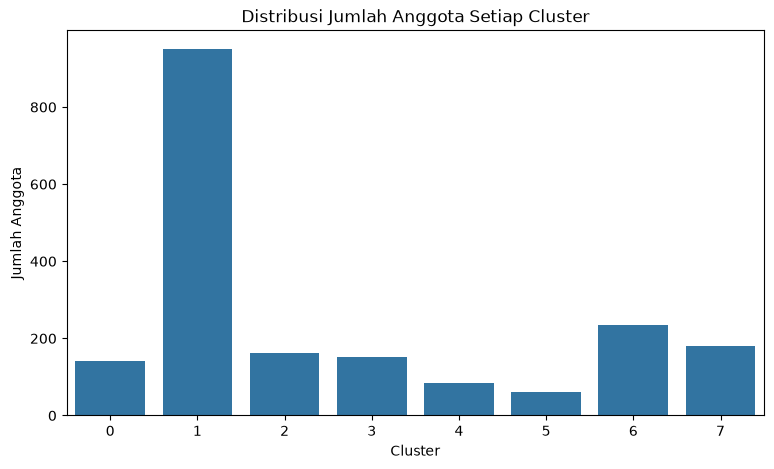

In [53]:
# Distribusi jumlah anggota setiap cluster
cluster_distribution = (
    pd.Series(final_labels, name='Cluster')
    .value_counts()
    .sort_index()
    .rename('Jumlah Anggota')
    .reset_index()
)

cluster_distribution['Persentase (%)'] = (
    cluster_distribution['Jumlah Anggota'] / len(final_labels) * 100
).round(2)

display(cluster_distribution)

plt.figure(figsize=(9, 5))
sns.barplot(data=cluster_distribution, x='Cluster', y='Jumlah Anggota')
plt.title('Distribusi Jumlah Anggota Setiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Anggota')
plt.show()


**Analisis**

Distribusi model final menunjukkan bahwa ukuran cluster tidak seimbang. Cluster terbesar berisi **951 pelanggan (48.40%)**, sedangkan cluster terkecil berisi **60 pelanggan (3.05%)**.

Ketidakseimbangan ini tidak otomatis berarti clustering gagal. Namun, cluster yang sangat besar perlu diperiksa lebih lanjut karena dapat menunjukkan kelompok pelanggan yang karakteristiknya masih cukup beragam. Sebaliknya, cluster kecil perlu dilihat apakah memiliki karakteristik khusus yang memang membedakannya dari kelompok lain.


## 3. Evaluasi Silhouette per Cluster


In [54]:
# Silhouette per observasi dan ringkasan per cluster
from sklearn.metrics import silhouette_samples
sample_silhouette = silhouette_samples(X, final_labels)

silhouette_cluster = (
    pd.DataFrame({
        'Cluster': final_labels,
        'Silhouette': sample_silhouette
    })
    .groupby('Cluster')['Silhouette']
    .agg(['mean', 'min', 'max', 'count'])
    .round(4)
)

display(silhouette_cluster)


,mean,min,max,count
Cluster,,,,
0,0.3708,0.2243,0.4311,142
1,0.2189,0.1343,0.3112,951
2,0.3400,0.2485,0.4166,161
3,0.3701,0.2863,0.4445,153
4,0.4439,0.3444,0.5204,85
5,0.5274,0.4416,0.6139,60
6,0.3153,0.2079,0.3966,234
7,0.3484,0.2530,0.4289,179


**Analisis**

Rata-rata silhouette berbeda antar-cluster sehingga kualitas pemisahan tidak
seragam. Pada model final, **Cluster 5 memiliki rata-rata silhouette tertinggi
(0,5274)**, sedangkan **Cluster 1 memiliki rata-rata terendah (0,2189)**.

Cluster dengan nilai rata-rata silhouette lebih rendah perlu diperiksa lebih
lanjut karena anggotanya relatif lebih dekat dengan cluster lain atau memiliki
karakteristik yang lebih beragam. Pemeriksaan per cluster melengkapi satu nilai
Silhouette Score global yang hanya memberikan rata-rata seluruh observasi.


## 4. Evaluasi Profil dan Keterbedaan Antar-Cluster


In [55]:
# Profil rata-rata numerik per cluster
numeric_profile_eval = (
    df_results.groupby('Cluster')[
        ['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size']
    ]
    .mean()
    .round(2)
)

display(numeric_profile_eval)


,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
Cluster,,,,,
0,47.75,110995.84,48.86,3.53,3.62
1,48.59,110130.25,51.91,4.14,3.74
2,46.62,111573.22,51.90,4.30,3.67
3,46.60,113770.13,49.90,4.25,3.97
4,45.82,107994.21,48.72,4.31,3.73
5,45.37,108758.62,46.38,6.13,4.05
6,51.16,110650.33,52.94,3.50,3.89
7,55.09,111161.24,48.97,3.96,3.58


**Analisis**

Profil numerik digunakan untuk memastikan bahwa cluster tidak hanya berbeda secara matematis, tetapi juga memiliki karakteristik pelanggan yang dapat dijelaskan. Perbedaan rata-rata pada usia, pendapatan, spending score, pengalaman kerja, dan ukuran keluarga menjadi dasar untuk memberi deskripsi pada setiap segmen.

Apabila perbedaan antar-cluster relatif kecil pada sebagian besar variabel, maka segmentasi perlu diinterpretasikan secara hati-hati karena beberapa kelompok memiliki karakteristik yang berdekatan.


In [56]:
# Profil profesi dan gender per cluster
profession_profile_eval = pd.crosstab(
    df_results['Cluster'], df_results['Profession'], normalize='index'
) * 100

gender_profile_eval = pd.crosstab(
    df_results['Cluster'], df_results['Gender'], normalize='index'
) * 100

print('Distribusi Profession (%)')
display(profession_profile_eval.round(2))

print('Distribusi Gender (%)')
display(gender_profile_eval.round(2))


Distribusi Profession (%)


Profession,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
Cluster,,,,,,,,,
0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,100.0,0.0
1,64.35,0.0,0.0,0.0,0.0,35.65,0.0,0.0,0.0
2,0.00,100.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
3,0.00,0.0,0.0,0.0,100.0,0.00,0.0,0.0,0.0
4,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,100.0
5,0.00,0.0,0.0,0.0,0.0,0.00,100.0,0.0,0.0
6,0.00,0.0,0.0,100.0,0.0,0.00,0.0,0.0,0.0
7,0.00,0.0,100.0,0.0,0.0,0.00,0.0,0.0,0.0


Distribusi Gender (%)


Gender,Female,Male
Cluster,,
0,60.56,39.44
1,60.57,39.43
2,55.28,44.72
3,56.86,43.14
4,62.35,37.65
5,65.00,35.00
6,56.84,43.16
7,57.54,42.46


**Analisis**

Distribusi kategori digunakan sebagai pelengkap profil numerik. Persentase
dihitung di dalam masing-masing cluster sehingga dapat dilihat apakah ada
profesi atau komposisi gender yang dominan pada segmen tertentu.

Pada model final, beberapa cluster sangat didominasi oleh satu kategori
`Profession`, sedangkan satu cluster merupakan kombinasi `Artist` dan
`Healthcare`. Temuan ini menunjukkan bahwa `Profession` berperan kuat dalam
pemisahan cluster. Hal tersebut kemudian diperiksa lebih lanjut melalui
Sensitivity Analysis, sehingga interpretasi tidak berhenti pada asumsi bahwa
cluster terutama dibentuk oleh fitur numerik.

Informasi kategorikal digunakan untuk menjelaskan karakteristik cluster,
bukan untuk menyimpulkan hubungan sebab-akibat.


## 5. Sensitivity Analysis — Pengaruh Fitur `Profession`

Profil cluster menunjukkan bahwa beberapa cluster sangat didominasi oleh
kategori `Profession`. Karena `Profession` merupakan fitur kategorikal yang
diubah menjadi dummy lalu ikut dihitung dalam jarak Euclidean K-Means,
diperlukan pemeriksaan sensitivitas untuk melihat seberapa besar struktur
clustering bergantung pada fitur tersebut.

Analisis ini tidak menggantikan model utama. Tujuannya adalah memahami apakah
pola cluster tetap kuat ketika `Profession` tidak digunakan.


In [57]:
# Membandingkan model dengan dan tanpa fitur Profession

features_without_profession = [
    'Gender',
    'Age',
    'Annual Income ($)',
    'Spending Score (1-100)',
    'Work Experience',
    'Family Size'
]

df_sensitivity = df_clean[features_without_profession].copy()
df_sensitivity['Gender'] = df_sensitivity['Gender'].map({'Male': 0, 'Female': 1})

scaler_sensitivity = StandardScaler()
X_without_profession = scaler_sensitivity.fit_transform(df_sensitivity)

sensitivity_results = []

for k in [7, 8, 9]:
    model_sensitivity = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels_sensitivity = model_sensitivity.fit_predict(X_without_profession)

    sensitivity_results.append({
        'K': k,
        'Silhouette Score': silhouette_score(X_without_profession, labels_sensitivity),
        'Calinski-Harabasz Index': calinski_harabasz_score(
            X_without_profession, labels_sensitivity
        ),
        'Davies-Bouldin Index': davies_bouldin_score(
            X_without_profession, labels_sensitivity
        )
    })

sensitivity_eval = pd.DataFrame(sensitivity_results)
display(sensitivity_eval.round(4))


,K,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,7,0.1445,241.0605,1.7756
1,8,0.1490,234.0845,1.6952
2,9,0.1504,226.5127,1.6409


**Analisis**

Ketika `Profession` dikeluarkan, kualitas internal clustering menurun cukup
jelas pada K=7–9. Pada K=8, misalnya, Silhouette Score turun menjadi sekitar
**0,1490** dibandingkan **0,2940** pada model utama.

Temuan ini menunjukkan bahwa `Profession` memberikan kontribusi besar terhadap
struktur cluster pada dataset ini. Dengan kata lain, segmentasi yang terbentuk
bukan hanya berasal dari fitur numerik seperti pendapatan atau spending score.

Hal ini bukan berarti `Profession` harus dihapus. Fitur tersebut memang dapat
relevan untuk segmentasi. Namun, hasil ini perlu dicantumkan sebagai bagian
dari interpretasi model agar pembaca memahami bahwa struktur cluster sangat
dipengaruhi oleh atribut profesi.


## 6. Evaluasi Visual dengan PCA


Explained variance PC1: 8.66 %
Explained variance PC2: 8.38 %
Total explained variance: 17.04 %


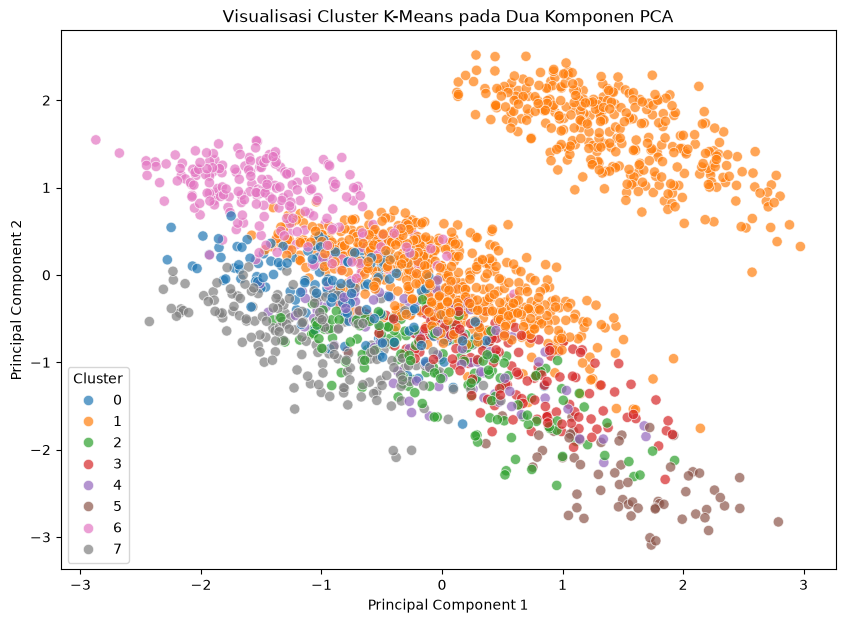

In [58]:
# Proyeksi PCA untuk membantu visualisasi hasil clustering
pca_eval = PCA(n_components=2)
X_pca_eval = pca_eval.fit_transform(X)

pca_eval_df = pd.DataFrame({
    'PC1': X_pca_eval[:, 0],
    'PC2': X_pca_eval[:, 1],
    'Cluster': final_labels
})

print('Explained variance PC1:', round(pca_eval.explained_variance_ratio_[0] * 100, 2), '%')
print('Explained variance PC2:', round(pca_eval.explained_variance_ratio_[1] * 100, 2), '%')
print('Total explained variance:', round(pca_eval.explained_variance_ratio_.sum() * 100, 2), '%')

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_eval_df,
    x='PC1', y='PC2', hue='Cluster',
    palette='tab10', s=55, alpha=0.7
)
plt.title('Visualisasi Cluster K-Means pada Dua Komponen PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


**Analisis**

Dua komponen PCA menjelaskan sekitar **17.04%** variasi data. Karena proporsi ini tidak mencakup seluruh informasi pada 14 fitur, visualisasi PCA hanya digunakan sebagai alat bantu untuk melihat pola umum dan kemungkinan overlap antar-cluster.

Model K-Means tidak dibangun pada dua komponen PCA tersebut. Model tetap menggunakan seluruh fitur hasil standardisasi sehingga visualisasi tidak boleh ditafsirkan sebagai representasi lengkap dari jarak antar pelanggan.


## 7. Evaluasi Stabilitas terhadap Random State


In [59]:
# Menguji konsistensi hasil K-Means pada beberapa random_state
seeds = [0, 21, 42, 99]
stability_results = []

for seed in seeds:
    model = KMeans(n_clusters=8, random_state=seed, n_init=20)
    labels_seed = model.fit_predict(X)
    stability_results.append({
        'Random State': seed,
        'Inertia': model.inertia_,
        'Silhouette Score': silhouette_score(X, labels_seed),
        'Calinski-Harabasz Index': calinski_harabasz_score(X, labels_seed),
        'Davies-Bouldin Index': davies_bouldin_score(X, labels_seed)
    })

stability_eval = pd.DataFrame(stability_results)
display(stability_eval.round(3))


,Random State,Inertia,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,0,13420.864,0.267,293.492,1.428
1,21,13406.160,0.266,294.121,1.415
2,42,13259.513,0.294,300.466,1.304
3,99,13420.864,0.267,293.492,1.428


**Analisis**

Hasil uji stabilitas menunjukkan adanya sensitivitas terhadap inisialisasi
K-Means. Pada empat `random_state` yang diuji, Silhouette Score berada pada
rentang **0,2660–0,2940**, sedangkan Davies-Bouldin Index berada pada rentang
**1,3035–1,4275**.

`random_state=42` menghasilkan nilai evaluasi terbaik di antara empat
percobaan yang diuji. Hal ini tidak berarti bahwa seed tersebut merupakan
konfigurasi yang selalu terbaik untuk seluruh dataset, tetapi menunjukkan
bahwa hasil K-Means pada dataset ini dipengaruhi oleh inisialisasi centroid.
Penggunaan `n_init=20` membantu memilih solusi yang lebih baik pada setiap
seed, tetapi tidak menghilangkan variasi sepenuhnya.


## 8. Kesimpulan Evaluation


### Kesimpulan Tahap Evaluation

Berdasarkan evaluasi model K-Means dengan **K=8**, terbentuk struktur cluster
yang dapat dianalisis menggunakan kombinasi metrik internal, distribusi
anggota, profil pelanggan, PCA, dan uji stabilitas.

Pada konfigurasi final `random_state=42` dan `n_init=20`, diperoleh:
- **Silhouette Score = 0,2940**
- **Calinski-Harabasz Index = 300,4657**
- **Davies-Bouldin Index = 1,3035**

Silhouette yang positif menunjukkan bahwa secara rata-rata observasi lebih
dekat dengan cluster-nya sendiri dibandingkan cluster lain, tetapi nilainya
juga menunjukkan bahwa pemisahan belum sempurna. Hasil ini perlu dibaca
sebagai evaluasi internal pada dataset dan fitur yang digunakan, bukan sebagai
bukti bahwa segmentasi sudah optimal secara bisnis.

Distribusi cluster menunjukkan ketidakseimbangan ukuran. Cluster terbesar
memuat **951 pelanggan (48,40%)**, sedangkan cluster terkecil memuat
**60 pelanggan (3,05%)**. Evaluasi silhouette per cluster menunjukkan bahwa
kualitas pemisahan juga berbeda antar-cluster.

Profiling memberikan temuan penting: beberapa cluster sangat didominasi oleh
kategori `Profession` tertentu, sementara perbedaan rata-rata beberapa fitur
numerik relatif lebih kecil. Oleh karena itu, hasil segmentasi perlu
dipahami sebagai struktur yang sangat dipengaruhi oleh kombinasi fitur yang
digunakan, khususnya `Profession`, bukan semata-mata sebagai segmentasi
perilaku pelanggan.

Uji stabilitas juga menunjukkan perubahan metrik ketika `random_state`
diubah. Dengan demikian, hasil clustering sebaiknya dipandang sebagai
segmentasi eksploratif pada dataset ini dan perlu divalidasi kembali apabila
data baru tersedia atau ketika akan digunakan untuk keputusan bisnis.


---
# Conclusion

Project ini membentuk segmentasi pelanggan menggunakan K-Means pada dataset `Customers.csv` dengan mengikuti tahapan CRISP-DM. Setelah 35 observasi dengan `Profession` kosong dihapus, model dibangun pada 1.965 observasi dan 14 fitur hasil encoding dan standardisasi.

Model akhir menggunakan K=8, `random_state=42`, dan `n_init=20`. Evaluasi internal menghasilkan Silhouette Score 0,2940, Calinski-Harabasz Index 300,4657, dan Davies-Bouldin Index 1,3035. Nilai tersebut menunjukkan bahwa struktur cluster terbentuk, tetapi antar-cluster belum terpisah secara tegas.

Tahap Evaluation juga menunjukkan tiga hal yang perlu diperhatikan saat membaca hasil. Pertama, ukuran cluster tidak seimbang karena satu cluster memuat 951 pelanggan (48,40%). Kedua, fitur `Profession` memiliki pengaruh besar terhadap struktur cluster. Ketiga, hasil K-Means masih sensitif terhadap `random_state`. Karena itu, hasil clustering dibaca sebagai segmentasi eksploratif pada dataset ini, bukan sebagai dasar keputusan bisnis otomatis.

`StandardScaler` dan model K-Means final kemudian disimpan pada tahap Deployment agar dapat digunakan oleh aplikasi Streamlit.


---
# Deployment

Tahap Deployment mengubah model yang sudah dilatih dan dievaluasi menjadi aplikasi yang dapat memprediksi cluster pelanggan. Aplikasi dibuat menggunakan **Streamlit** dan disimpan pada folder `streamlit/`.

Alur yang digunakan adalah sebagai berikut.

```text
Notebook (training)
    ↓
Preprocessing → Encoding → StandardScaler → K-Means (K=8) → Evaluation
    ↓
Simpan scaler_customer.joblib dan kmeans_customer.joblib
    ↓
Aplikasi Streamlit
    ↓
Load kedua file joblib
    ↓
Input customer → Preprocessing input → scaler.transform() → kmeans.predict()
    ↓
Tampilkan Prediksi Cluster
```

Model yang digunakan aplikasi adalah model yang dilatih pada notebook ini. Streamlit **tidak melatih ulang** K-Means. Aplikasi hanya melakukan preprocessing input, transformasi menggunakan scaler, dan prediksi cluster menggunakan model yang sudah tersimpan.

Struktur folder project:

```text
tugas_mandiri/
├── notebook/
│   └── clustering_final_crispdm.ipynb
├── dataset/
│   └── Customers.csv
└── streamlit/
    ├── app.py
    ├── requirements.txt
    ├── scaler_customer.joblib
    ├── kmeans_customer.joblib
    ├── Customers.csv
    └── README.md
```


## 1. Menyimpan Scaler dan Model

Notebook berada di `tugas_mandiri/notebook/`, sedangkan aplikasi berada di `tugas_mandiri/streamlit/`. Karena itu, file artefak disimpan ke `../streamlit/` agar langsung berada di folder aplikasi.


In [60]:
import joblib
from pathlib import Path

# Notebook berada di tugas_mandiri/notebook/, artefak disimpan ke tugas_mandiri/streamlit/
STREAMLIT_DIR = Path("../streamlit")
STREAMLIT_DIR.mkdir(exist_ok=True)

SCALER_PATH = STREAMLIT_DIR / "scaler_customer.joblib"
MODEL_PATH = STREAMLIT_DIR / "kmeans_customer.joblib"

# scaler: StandardScaler yang di-fit pada df_encoded (Data Preparation)
# kmeans_final: K-Means final (K=8, random_state=42, n_init=20)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(kmeans_final, MODEL_PATH)

print("Scaler disimpan ke:", SCALER_PATH.resolve())
print("Model disimpan ke :", MODEL_PATH.resolve())


Scaler disimpan ke: C:\Users\shsen\Documents\SEMESTER_7\DataScience\tugas_mandiri\tugas_mandiri\streamlit\scaler_customer.joblib
Model disimpan ke : C:\Users\shsen\Documents\SEMESTER_7\DataScience\tugas_mandiri\tugas_mandiri\streamlit\kmeans_customer.joblib


**Analisis**

`StandardScaler` dan model K-Means final disimpan dalam format Joblib agar dapat digunakan kembali oleh aplikasi Streamlit tanpa melakukan proses training ulang. Scaler ikut disimpan karena model dilatih pada data yang sudah distandardisasi, sehingga data pelanggan baru harus ditransformasi dengan parameter (mean dan standar deviasi) yang sama seperti saat training.


## 2. Verifikasi File Artefak


In [61]:
# Memuat kembali kedua file untuk memastikan file dapat dibaca dan konfigurasinya sesuai
import sklearn

scaler_loaded = joblib.load(SCALER_PATH)
kmeans_loaded = joblib.load(MODEL_PATH)

print("File scaler :", SCALER_PATH.name, f"({SCALER_PATH.stat().st_size / 1024:.1f} KB)")
print("File model  :", MODEL_PATH.name, f"({MODEL_PATH.stat().st_size / 1024:.1f} KB)")
print()
print("Versi scikit-learn saat training :", sklearn.__version__)
print("Jumlah fitur pada scaler :", scaler_loaded.n_features_in_)
print("n_clusters               :", kmeans_loaded.n_clusters)
print("random_state             :", kmeans_loaded.random_state)
print("n_init                   :", kmeans_loaded.n_init)
print()
print("Urutan fitur yang diharapkan model:")
print(list(scaler_loaded.feature_names_in_))
print()
print("Urutan fitur sama dengan df_encoded:",
      list(scaler_loaded.feature_names_in_) == list(df_encoded.columns))


File scaler : scaler_customer.joblib (1.4 KB)
File model  : kmeans_customer.joblib (9.3 KB)

Versi scikit-learn saat training : 1.8.0
Jumlah fitur pada scaler : 14
n_clusters               : 8
random_state             : 42
n_init                   : 20

Urutan fitur yang diharapkan model:
['Gender', 'Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size', 'Profession_Doctor', 'Profession_Engineer', 'Profession_Entertainment', 'Profession_Executive', 'Profession_Healthcare', 'Profession_Homemaker', 'Profession_Lawyer', 'Profession_Marketing']

Urutan fitur sama dengan df_encoded: True


**Analisis**

File artefak model berhasil disiapkan dan dapat dimuat kembali. Konfigurasi yang terbaca sesuai dengan model final, yaitu K=8, `random_state=42`, dan `n_init=20`. Scaler menyimpan nama dan urutan 14 fitur hasil Data Preparation. Informasi ini digunakan aplikasi Streamlit sebagai acuan agar kolom input selalu sama dengan kolom saat training.

Versi `scikit-learn` saat training juga dicetak. File Joblib sebaiknya dibaca dengan versi `scikit-learn` yang sama, sehingga versi tersebut perlu disamakan dengan yang tertulis pada `streamlit/requirements.txt`.


## 3. Preprocessing Input dan Uji Konsistensi

Data pelanggan baru harus diproses dengan langkah yang sama seperti pada Data Preparation, yaitu mapping `Gender`, One-Hot Encoding `Profession`, dan penyesuaian kolom sesuai urutan fitur training. Fungsi `preprocess_input()` di bawah ini identik dengan fungsi yang digunakan pada `app.py`.

Pada saat training, `Profession` di-encode dengan `drop_first=True`. Pada input tunggal, `drop_first` tidak dapat dipakai karena hanya ada satu baris data. Oleh karena itu, input di-encode penuh terlebih dahulu, lalu kolom disesuaikan dengan `reindex` ke daftar fitur training. Kolom kategori yang tidak ada pada training (`Profession_Artist`) otomatis dihapus sehingga hasilnya setara dengan `drop_first=True`.


In [62]:
GENDER_MAP = {"Male": 0, "Female": 1}


def preprocess_input(df_input, feature_columns):
    """Preprocessing input pelanggan (sama dengan fungsi pada app.py)."""
    df_proc = df_input.copy()
    df_proc["Gender"] = df_proc["Gender"].map(GENDER_MAP)
    df_proc = pd.get_dummies(df_proc, columns=["Profession"], prefix="Profession")
    df_proc = df_proc.reindex(columns=feature_columns, fill_value=0)
    return df_proc.astype(float)


feature_columns = list(scaler_loaded.feature_names_in_)

# Uji konsistensi: seluruh data training diproses ulang melalui jalur deployment
X_check = scaler_loaded.transform(preprocess_input(df_clean, feature_columns))
labels_check = kmeans_loaded.predict(X_check)

print("Matriks fitur sama dengan X pada training :", np.allclose(X_check, X))
print("Label prediksi sama dengan label training  :", np.array_equal(labels_check, final_labels))


Matriks fitur sama dengan X pada training : True
Label prediksi sama dengan label training  : True


**Analisis**

Uji konsistensi memproses seluruh 1.965 observasi melalui jalur yang sama dengan aplikasi, yaitu `preprocess_input()`, `scaler.transform()`, dan `kmeans.predict()`. Hasilnya, matriks fitur dan label cluster sama dengan hasil training. Hal ini menunjukkan bahwa preprocessing aplikasi menghasilkan jumlah fitur, urutan fitur, dan encoding yang sama dengan notebook.


## 4. Contoh Prediksi Cluster


In [63]:
# Contoh input satu pelanggan (nilai contoh, bukan bagian dari dataset)
contoh_pelanggan = pd.DataFrame([{
    "Gender": "Female",
    "Age": 35,
    "Annual Income ($)": 90000,
    "Spending Score (1-100)": 60,
    "Profession": "Engineer",
    "Work Experience": 8,
    "Family Size": 3,
}])

X_contoh = scaler_loaded.transform(preprocess_input(contoh_pelanggan, feature_columns))
cluster_contoh = kmeans_loaded.predict(X_contoh)[0]

print(f"Prediksi Cluster: Cluster {cluster_contoh}")


Prediksi Cluster: Cluster 7


**Analisis**

Satu data pelanggan diubah menjadi DataFrame, diproses dengan `preprocess_input()`, distandardisasi dengan scaler, lalu diprediksi oleh model K-Means. Nomor cluster yang dihasilkan menunjukkan centroid terdekat pada ruang fitur terstandardisasi. Nomor tersebut merupakan label numerik dan maknanya mengikuti profil cluster pada tahap Evaluation.


## 5. Penjelasan Kode Aplikasi Streamlit

Aplikasi berada pada `streamlit/app.py`. Fungsi setiap bagian aplikasi adalah sebagai berikut.

| Bagian pada `app.py` | Fungsi |
|---|---|
| `load_artifacts()` | Memuat `scaler_customer.joblib` dan `kmeans_customer.joblib` dengan `joblib.load()`. Hasilnya di-cache sehingga file tidak dibaca ulang pada setiap interaksi. |
| `load_data()` | Membaca `Customers.csv` untuk menyediakan pilihan `Profession`, rentang nilai input, dan bahan profil cluster. Baris dengan `Profession` kosong dihapus seperti pada notebook. |
| Form input | `st.selectbox()` dan `st.number_input()` menerima tujuh fitur pelanggan: `Gender`, `Age`, `Annual Income ($)`, `Spending Score (1-100)`, `Profession`, `Work Experience`, dan `Family Size`. |
| `preprocess_input()` | Mengubah input menjadi DataFrame, memetakan `Gender`, melakukan One-Hot Encoding pada `Profession`, dan menyesuaikan kolom dengan `scaler.feature_names_in_`. |
| `scaler.transform()` | Menstandardisasi fitur menggunakan mean dan standar deviasi hasil training. |
| `kmeans.predict()` | Menentukan cluster dengan centroid terdekat. Tidak ada `fit()` pada aplikasi. |
| Tampilan hasil | Menampilkan `Prediksi Cluster: Cluster X` dan profil ringkas cluster tersebut, yang dihitung dari data training melalui jalur prediksi yang sama. |

Aplikasi dijalankan dari folder `streamlit/` dengan perintah berikut.

```bash
cd ../streamlit
streamlit run app.py
```

## 6. Ringkasan Hasil Segmentasi sebagai Output Pendukung

Selain aplikasi prediksi, hasil segmentasi pada seluruh data training tetap disediakan sebagai dataset berlabel `Cluster` dan tabel ringkasan profil cluster.


In [64]:
# Menyiapkan dataset hasil segmentasi untuk digunakan pada analisis lanjutan

deployment_output = df_results.copy()

print("Jumlah observasi:", deployment_output.shape[0])
print("Jumlah kolom:", deployment_output.shape[1])
print("Kolom output:")
print(deployment_output.columns.tolist())

display(deployment_output.head())


Jumlah observasi: 1965
Jumlah kolom: 8
Kolom output:
['Gender', 'Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Profession', 'Work Experience', 'Family Size', 'Cluster']


,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Cluster
0,Male,19,15000,39,Healthcare,1,4,1
1,Male,21,35000,81,Engineer,3,3,7
2,Female,20,86000,6,Engineer,1,1,7
3,Female,23,59000,77,Lawyer,0,2,0
4,Female,31,38000,40,Entertainment,2,6,6


**Analisis**

Dataset deployment mempertahankan atribut pelanggan dalam bentuk yang mudah
dibaca serta menambahkan kolom `Cluster`. Dengan demikian, hasil model dapat
ditelusuri kembali ke karakteristik pelanggan tanpa harus membaca hasil
centroid dalam ruang fitur terstandardisasi.

Output ini dapat digunakan sebagai basis analisis lanjutan, misalnya membuat
ringkasan setiap segmen atau menggabungkannya dengan data transaksi apabila
data tersebut tersedia.


In [65]:
# Membuat ringkasan profil cluster untuk kebutuhan deployment

cluster_profile_deployment = (
    deployment_output.groupby('Cluster')
    .agg(
        Jumlah_Pelanggan=('Cluster', 'size'),
        Rata2_Age=('Age', 'mean'),
        Rata2_Income=('Annual Income ($)', 'mean'),
        Rata2_Spending_Score=('Spending Score (1-100)', 'mean'),
        Rata2_Work_Experience=('Work Experience', 'mean'),
        Rata2_Family_Size=('Family Size', 'mean')
    )
    .reset_index()
)

cluster_profile_deployment['Persentase (%)'] = (
    cluster_profile_deployment['Jumlah_Pelanggan']
    / len(deployment_output) * 100
)

display(cluster_profile_deployment.round(2))


,Cluster,Jumlah_Pelanggan,Rata2_Age,Rata2_Income,Rata2_Spending_Score,Rata2_Work_Experience,Rata2_Family_Size,Persentase (%)
0,0,142,47.75,110995.84,48.86,3.53,3.62,7.23
1,1,951,48.59,110130.25,51.91,4.14,3.74,48.40
2,2,161,46.62,111573.22,51.90,4.30,3.67,8.19
3,3,153,46.60,113770.13,49.90,4.25,3.97,7.79
4,4,85,45.82,107994.21,48.72,4.31,3.73,4.33
5,5,60,45.37,108758.62,46.38,6.13,4.05,3.05
6,6,234,51.16,110650.33,52.94,3.50,3.89,11.91
7,7,179,55.09,111161.24,48.97,3.96,3.58,9.11


**Analisis**

Ringkasan ini memberikan representasi sederhana mengenai ukuran dan
karakteristik numerik setiap cluster. Tabel tersebut dapat digunakan sebagai
output operasional untuk membaca segmentasi tanpa menjalankan kembali proses
clustering.

Interpretasi bisnis tetap harus mempertimbangkan distribusi `Profession`,
ketidakseimbangan ukuran cluster, sensitivitas terhadap `random_state`, serta
kualitas metrik internal. Karena project tidak memiliki data outcome bisnis,
hasil cluster belum dapat digunakan untuk menyatakan bahwa satu segmen pasti
lebih bernilai atau memerlukan strategi tertentu.


### Keterbatasan

1. Dataset tidak memiliki label target atau outcome bisnis.
2. Kualitas cluster bergantung pada fitur dan transformasi yang digunakan.
3. `Profession` memberikan pengaruh besar terhadap struktur cluster.
4. Terdapat nilai `Age = 0` dan `Annual Income ($)` sangat rendah yang
   dipertahankan karena belum dapat diverifikasi sebagai kesalahan data.
5. K-Means menunjukkan sensitivitas terhadap `random_state`.

Dengan keterbatasan tersebut, deployment yang tepat pada project ini adalah
menjadikan hasil clustering sebagai **alat bantu segmentasi dan eksplorasi**,
bukan sebagai sistem pengambilan keputusan otomatis.
